1. map L1 and L2, the track from cry2ce variable number doesn't match

updates:
2025/4/14
retracking way 

updates:
2025/4/16
check sha

updates: 2025/4/23 

check sea surface height --> lead distribution selection

batch processing to get a region result

updates: 2025/4/29
batch processing 
not use modules, but just do a little change

updates:2025/5/7 batch processing, add waveform filtering, 

region clip

correction data前置，保证范围一致

update:2025/6/4 L2 broadcast correction value

update: 2026/3/9
1. SARin 模式的第一个峰值阈值错误 在代码中，将 SARin 的 threshold_first_max 设置为了 0.5。

文档要求：对于 SARin 模式，检测第一个极大值的阈值应为 0.45。

2. 重定轨阈值（50%）的计算逻辑偏移
代码直接使用了固定的 retrack_threshold = 0.5（假设归一化后全局最大值是 1.0）。

文档要求：位置估计应该是上升到“第一个极大值功率的 50%”（50% of the power of the first maximum）。

潜在问题：如果波形的第一个极大值（First Maximum）不是全局最大值（例如只有 0.8），那么 50% 的断点应该是 0.4 而非 0.5。
actual_threshold = waveform[max_idx] * 0.5  # 使用第一个峰值功率的 50%
3. 寻找前缘（Leading Edge）的搜索方向
4. 你的代码使用 for j in range(max_idx) 从头开始寻找交点。

潜在问题：如果波形起始部分有噪声波动，可能会触发错误的“伪交点”。

修正建议：通常建议从 max_idx 反向搜索，找到第一个低于 50% 阈值的点，这样能确保你定位的是紧邻该峰值的“前缘（Leading Edge）”

1. SLA filter size
代码问题：你在 rolling 和 uniform_filter1d 中都使用了 window=5 或 size=5。

文档要求：文档明确要求使用 100 km 的方框滤波器（Box filter）。

修正建议：你需要根据数据的采样间隔（Along-track 约为 380m）计算 100 km 对应的点数。例如：size = 100000 / 380 ≈ 263。

2. 缺失 200 km 距离限制掩膜
代码问题：你的代码通过 extrapolate 填充了全轨迹，但没有进行距离检查。文档要求：如果距离最近的原始冰缝（$sla_{raw}$）观测点超过滤波器尺寸的两倍（即 200 km），结果必须设为 NaN。修正建议：在插值后，计算每个点到最近 lead 点的距离，超过 200 km 的部分需置为 np.nan。

文档步骤：对现有的 $sla_{raw}$ 观测值进行 100 km 平滑。在平滑后的观测值之间进行全轨迹线性插值。对插值后的全轨迹再次进行 100 km 平滑。代码对比：你的 Step 1 是在有效 lead 点上做 rolling，这符合“仅应用于现有观测”的要求。但你的 Step 3（二次平滑）使用的是 nearest 填充后的数组，这可能在数据边缘引入台阶状伪影。4. 关于线性插值（Interpolation）的设置代码问题：使用了 fill_value="extrapolate"。文档建议：虽然文档提到线性插值覆盖整个轨迹，但由于 Step 4 的存在，超出 200 km 的外推（Extrapolation）实际上是无效的。建议在插值时结合距离判断，确保外推不会导致不可靠的远距离预测。

修改代码适配SARin

update: PlanB 裁剪到一致128？ 然后进行计算 再返回索引值，这样先保证有参考分类阈值

# consistent explanation

In [6]:
c = 299792458  # 光速 (m/s)
# 建议根据文件名自动判定模式
mode = "SARin"
if  mode == "SARin":
    range_bins = 1024 #
    tfmra_peak_threshold = 0.45 # SARin 模式首峰检测门槛
    reference_point = 512
else:
    range_bins = 256 # 注意：SAR 模式是 128 而非 256
    tfmra_peak_threshold = 0.15 # SAR 模式首峰检测门槛
    reference_point = 128
L1_path = r"E:\NWP\CS2_L1\2022\CS_OFFL_SIR_SIN_1B_20220323T224728_20220323T224947_E001.nc"
L2_path = r"E:\NWP\CS2_L2_within_region\2022\CS_OFFL_SIR_SIN_2__20220323T224728_20220323T224947_E001.nc"# 读取研究区域 shp 文件
region_shp = r"C:\Users\TJ002\Desktop\code\Cal_code_data\NWP_orbit_processing\Arctic_Canada_North.shp"

In [7]:
range_bins

1024

# region select

In [8]:
import xarray as xr
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata
# 读取研究区域的 Shapefile
region_gdf = gpd.read_file(region_shp)

# 确保 Shapefile 采用 WGS84 坐标系
if region_gdf.crs is None or region_gdf.crs.to_epsg() != 4326:
    region_gdf = region_gdf.to_crs(epsg=4326)

# 获取 Shapefile 边界框
# 获取边界范围
#min_lon, min_lat, max_lon, max_lat = region_gdf.total_bounds
min_lon, max_lon = -130, -120
min_lat, max_lat = 73, 77
print(f"Region boundary: lon({min_lon}, {max_lon}), lat({min_lat}, {max_lat})")

Region boundary: lon(-130, -120), lat(73, 77)


# waveform filter

first peak > 80% max

暂时不加，想起tilling文章关于 retracking有多波峰的筛选，后期确认后再加

In [9]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

def filter_valid_waveforms(df, waveform_array, method='simple', threshold=0.8):
    """
    Filter waveforms where the first peak is >= threshold * max value of the waveform.

    Parameters:
    - df: pd.DataFrame
        The dataframe containing the metadata (same length as waveform_array).
    - waveform_array: np.ndarray
        The 2D waveform array of shape (n_samples, n_bins).
    - method: str
        'simple' uses the first value as the first peak;
        'peak' uses scipy to find the first real peak.
    - threshold: float
        Threshold ratio of first peak to max (default: 0.8).

    Returns:
    - df_valid: pd.DataFrame
        Filtered dataframe containing only valid waveforms.
    - valid_waveforms: np.ndarray
        Corresponding waveforms that passed the check.
    """

    valid_mask = []

    for waveform in waveform_array:
        if method == 'simple':
            first_peak = waveform[0]
        elif method == 'peak':
            peaks, _ = find_peaks(waveform)
            if len(peaks) == 0:
                valid_mask.append(False)
                continue
            first_peak = waveform[peaks[0]]
        else:
            raise ValueError("method must be 'simple' or 'peak'")

        max_power = np.max(waveform)
        valid_mask.append(first_peak >= threshold * max_power)

    valid_mask = np.array(valid_mask)
    df_valid = df[valid_mask].reset_index(drop=True)
    valid_waveforms = waveform_array[valid_mask]

    return df_valid, valid_waveforms


# L1 data read

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xarray as xr
from datetime import datetime, timedelta

ds = xr.open_dataset(L1_path)

# Read time and waveform data (automatically mapped)
time_20_ku = ds['time_20_ku'].values
time_1hz = ds['time_plrm_01_ku'].values
lat_20_ku = ds['lat_20_ku'].values
lon_20_ku = ds['lon_20_ku'].values

waveform_20_ku = ds['pwr_waveform_20_ku'].values
waveform_plrm_01_ku = ds['pwr_waveform_plrm_01_ku'].values

noise_power_20_ku = ds['noise_power_20_ku'].values 
noise_power_real = np.where(noise_power_20_ku == -9999.99, np.nan, noise_power_20_ku )

stack_std_20_ku = ds['stack_std_20_ku'].values #* 0.01
stack_peakiness_20_ku = ds['stack_peakiness_20_ku'].values # * 0.01
stack_kurtosis_20_ku = ds['stack_kurtosis_20_ku'].values #* 0.01 
window_del_20_ku = ds['window_del_20_ku'].values #*1e-12
tai_epoch = datetime(2000, 1, 1, 0, 0, 0)
alt = ds['alt_20_ku'].values
#alt_01 = ds['alt_plrm_01_ku'].values

def tai_to_utc(tai_seconds): # 将 TAI 秒数转换为 UTC 时间 
    utc_time = tai_epoch + timedelta(seconds=tai_seconds) 
    return utc_time

# Convert datetime64[ns] to seconds since epoch
tai_seconds = (time_20_ku - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
utc_time = np.array([tai_to_utc(t) for t in tai_seconds])


surf_type = ds["surf_type_01"].values  # 低频地表类型
ind_first_meas = ds["ind_first_meas_20hz_01"]#.values.astype(int)  # 对应的索引
# 20Hz 维度大小
N_20 = lat_20_ku.shape[0]

# 预填充 20Hz 的 surf_type 数组
surf_type_20hz = np.full(N_20, np.nan)

# 扩展 1Hz 的地表类型到 20Hz
for i in range(len(ind_first_meas)):
    start_idx = int(ind_first_meas[i])
    end_idx = min(start_idx + 20, N_20)  # 确保不越界
    surf_type_20hz[start_idx:end_idx] = surf_type[i]

# 确保 NetCDF 变量的维度名称正确
time_dim = "time_20_ku"  # 确保这个名字匹配 ds 的 20Hz 维度
if time_dim not in ds.dims:
    print("Warning: 维度名称不匹配，请检查 NetCDF 结构！")
    print(ds)  # 打印数据集以检查正确的维度名称
else:
    # 赋值前创建可修改副本
    ds = ds.copy()   
    # 添加新变量
    ds["surf_type_20hz"] = (time_dim,), surf_type_20hz
    
# 假设你想创建一个 DataFrame 来存储所有这些变量
df = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'alt':alt,
    #'waveform_20_ku': list(waveform_20_ku),
    'noise_power_real': noise_power_real,
    'std': stack_std_20_ku,
    'pp': stack_peakiness_20_ku,
    'k': stack_kurtosis_20_ku,
    'lat': lat_20_ku,
    'lon': lon_20_ku,
    'surf_type': surf_type_20hz,
    'window_del': window_del_20_ku
    #'waveform_20_ku': list(waveform_20_ku)
})

# 假设 df['window_del'] 是 timedelta64 类型
df['window_del_seconds'] = df['window_del'].dt.total_seconds() 

# 动态获取当前文件的 range bin 数量
n_bins = waveform_20_ku.shape[1] 
print(f"Detected Mode: {'SARin' if n_bins == 512 else 'SAR'} (Bins: {n_bins})")

Detected Mode: SAR (Bins: 1024)


In [11]:
def process_waveform_tilling_2018(waveform_array, ssd_array, mode):
    """
    根据 Tilling et al. (2018) 裁剪波形，计算自定义 PP，并分类。
    """
    n_samples = len(waveform_array)
    types = np.full(n_samples, 'unknown', dtype=object)
    absolute_offsets = np.full(n_samples, np.nan)
    custom_pps = np.full(n_samples, np.nan)
    
    # 根据模式设定 SSD 阈值 [cite: 226, 227]
    ssd_threshold = 6.29 if mode == "SAR" else 4.62
    
    cropped_waveforms = []

    for i in range(n_samples):
        wf = waveform_array[i]
        ssd = ssd_array[i]
        
        # --- 1. 裁剪波形到 128 bins ---
        b_max = np.argmax(wf)
        start_index = b_max - 50
        end_index = b_max + 77 + 1
        
        pad_left = max(0, -start_index)
        pad_right = max(0, end_index - len(wf))
        
        start_idx_safe = max(0, start_index)
        end_idx_safe = min(len(wf), end_index)
        
        cropped_wf = wf[start_idx_safe:end_idx_safe]
        
        if pad_left > 0 or pad_right > 0:
            cropped_wf = np.pad(cropped_wf, (pad_left, pad_right), 'constant', constant_values=0)
            
        cropped_waveforms.append(cropped_wf)
        absolute_offsets[i] = b_max - 50
        
        # --- 2. 手动计算 Tilling 等人的 PP (Pulse Peakiness) ---
        # 噪声底板定义为 bin 10 到 19 的平均功率 
        # 注意：这里的 10-19 是裁剪后 128-bin 数组里的相对索引
        noise_floor = np.mean(cropped_wf[10:20]) 
        
        # 仅计算高于噪声底板的 bin 的均值 
        valid_bins = cropped_wf[cropped_wf > noise_floor]
        
        if len(valid_bins) > 0:
            p_mean = np.mean(valid_bins)
            p_max = np.max(cropped_wf)
            pp = p_max / p_mean if p_mean > 0 else 0
        else:
            pp = 0
            
        custom_pps[i] = pp
        
        # --- 3. 严格执行分类逻辑 ---
        # 镜面回波 (Lead) 
        if pp > 18 and ssd < ssd_threshold:
            types[i] = 'lead'
        # 漫反射回波 (Ice floe) 
        elif pp < 9 and ssd > ssd_threshold:
            types[i] = 'ice'
            
    return types, custom_pps, absolute_offsets, np.array(cropped_waveforms)

In [12]:
waveform_data = waveform_20_ku 
ssd_data = df['std'].values

# 获取分类结果、自定义 PP、以及我们之前强调过的绝对偏移量
classified_types, calculated_pps, abs_offsets, cropped_wfs = process_waveform_tilling_2018(
    waveform_data, ssd_data, mode
)

# 将结果存回 DataFrame
df['type'] = classified_types
df['tilling_pp'] = calculated_pps
df['abs_offset'] = abs_offsets
df['cropped_waveform'] = list(cropped_wfs)

print(f"[{mode} Mode] Lead count (Tilling 2018 method): {np.sum(df['type'] == 'lead')}")
print(f"[{mode} Mode] Ice count (Tilling 2018 method): {np.sum(df['type'] == 'ice')}")

[SARin Mode] Lead count (Tilling 2018 method): 843
[SARin Mode] Ice count (Tilling 2018 method): 1491


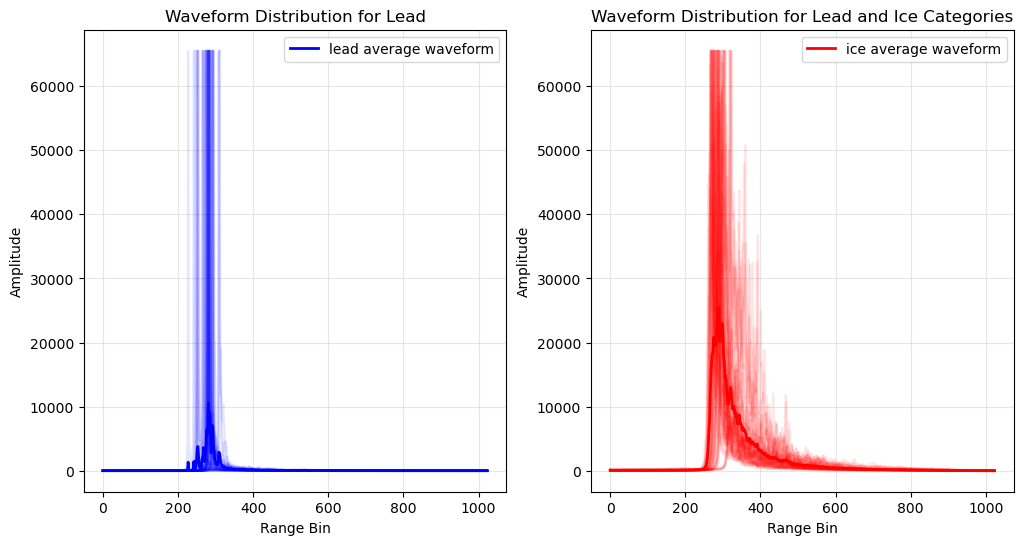

-185.16
-187.94


In [36]:
# Plot waveforms for 'lead' and 'ice' categories
plt.figure(figsize=(12, 6))

# Plot waveforms for 'lead' category
plt.subplot(1, 2, 1)
lead_mask = df['type'] == 'lead'
if lead_mask.any():
    for waveform in waveform_20_ku[lead_mask][:50]:  # Only plot the first 50 waveforms
        plt.plot(waveform, color='blue', alpha=0.1)
    plt.plot(waveform_20_ku[lead_mask][:50].mean(axis=0), label='lead average waveform', color='blue', linewidth=2)
plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Lead')
plt.legend()
plt.grid(alpha=0.3)

# Plot waveforms for 'ice' category
plt.subplot(1, 2, 2)
ice_mask = df['type'] == 'ice'
if ice_mask.any():
    for waveform in waveform_20_ku[ice_mask][:50]:  # Only plot the first 50 waveforms
        plt.plot(waveform, color='red', alpha=0.1)
    plt.plot(waveform_20_ku[ice_mask][:50].mean(axis=0), label='ice average waveform', color='red', linewidth=2)
plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Ice')
plt.legend()
plt.grid(alpha=0.3)

plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Lead and Ice Categories')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(noise_power_20_ku[100])
print(noise_power_20_ku[1000])

In [47]:
import numpy as np
import scipy.signal
import scipy.ndimage
import matplotlib.pyplot as plt

# 物理常量与参数定义
c = 299792458  # 光速 (m/s)
bin_size = 0.2342  # 每个 bin 代表的物理距离 (m)
def crop_waveform_and_get_offset(waveform):
    """提取 128 bins 并保留绝对偏移量"""
    b_max = np.argmax(waveform)
    start_index = b_max - 50
    end_index = b_max + 77 + 1 
    
    pad_left = max(0, -start_index)
    pad_right = max(0, end_index - len(waveform))
    start_idx_safe = max(0, start_index)
    end_idx_safe = min(len(waveform), end_index)
    
    cropped_wf = waveform[start_idx_safe:end_idx_safe]
    if pad_left > 0 or pad_right > 0:
        cropped_wf = np.pad(cropped_wf, (pad_left, pad_right), 'constant', constant_values=0)
        
    absolute_offset = b_max - 50
    return cropped_wf, absolute_offset

def retrack_diffuse_waveform_tilling(waveform_array, mode="SARin"):
    """
    遵循 Tilling et al. (2018) 针对漫反射回波(Ice)的 70% 阈值重追踪算法。
    """
    n_samples = len(waveform_array)
    range_correction = np.full(n_samples, np.nan)
    
    # # 确定不同模式的标称追踪点 (bn)
    # b_n = 512 if mode == "SARin" else 128
    # 动态计算你的数据的真实参考中心
    total_bins = waveform_array.shape[1]
    b_n = total_bins // 2 
    
    for i in range(n_samples):
        raw_wf = waveform_array[i]
        
        # 1. 裁剪并获取绝对坐标偏移量 (Absolute Offset)
        cropped_wf, abs_offset = crop_waveform_and_get_offset(raw_wf)
        
        # 2. 三点移动平均平滑 (文献明确要求 3-point moving average)
        smoothed_wf = scipy.ndimage.uniform_filter1d(cropped_wf, size=3)
        
        # 3. 寻找第一个符合条件的波峰 (>= 20% 最大振幅)
        max_val = np.max(smoothed_wf)
        if max_val <= 0:
            continue
            
        peak_threshold = 0.20 * max_val
        peaks, _ = scipy.signal.find_peaks(smoothed_wf)
        valid_peaks = [p for p in peaks if smoothed_wf[p] >= peak_threshold]
        
        if not valid_peaks:
            continue
            
        first_peak_idx = valid_peaks[0]
        first_peak_val = smoothed_wf[first_peak_idx]
        
        # 4. 定位 70% 阈值点
        threshold_70 = 0.70 * first_peak_val
        b_0_local = np.nan
        
        # 从第一峰向左回溯，寻找跨越 70% 阈值的两个点
        for j in range(first_peak_idx - 1, -1, -1):
            if smoothed_wf[j] <= threshold_70 <= smoothed_wf[j + 1]:
                # 线性插值，计算小窗内的相对十进制 bin 编号
                frac = (threshold_70 - smoothed_wf[j]) / (smoothed_wf[j + 1] - smoothed_wf[j])
                b_0_local = j + frac
                break
                
        if np.isnan(b_0_local):
            continue
            
        # 5. 【奇迹发生的一步】将相对编号还原为全局绝对编号 (b_0)
        b_0_global = abs_offset + b_0_local
        
        # 6. 计算重追踪距离校正 C_R = (b_0 - b_n) * delta_b
        range_correction[i] = (b_0_global - b_n) * bin_size

    return range_correction
import numpy as np
from scipy.optimize import curve_fit

def giles_echo_function(t, a, t0, k, sigma):
    """
    Tilling 2018 中定义的 Giles 镜面回波拟合函数。
    t: 波形的 x 轴索引 (0 到 127)
    a: 波形最大振幅 
    t0: 重跟踪点（我们真正要求的值）
    k: 指数衰减速率参数 
    sigma: 高斯函数的标准差（前沿宽度） 
    """
    # 增加微小保护值，防止在优化过程中除以 0 或计算负数平方根
    sigma = max(sigma, 1e-6)
    k = max(k, 1e-6)
    
    # 预计算文献中的 tb 和平滑连接段系数 a2, a3 [cite: 287, 298]
    tb = k * (sigma**2)
    sqrt_k_tb = np.sqrt(k * tb)
    
    a2 = (5 * k * sigma - 4 * sqrt_k_tb) / (2 * sigma * tb * sqrt_k_tb)
    a3 = (2 * sqrt_k_tb - 3 * k * sigma) / (2 * sigma * (tb**2) * sqrt_k_tb)
    
    # 初始化分段函数 f(t) 的数组
    f = np.zeros_like(t, dtype=float)
    
    # === 条件 1: 前沿 (Gaussian) [cite: 284] ===
    mask1 = t < t0
    f[mask1] = (t[mask1] - t0) / sigma
    
    # === 条件 2: 连接段 (Linking function) [cite: 285] ===
    mask2 = (t >= t0) & (t < (tb + t0))
    dt2 = t[mask2] - t0
    f[mask2] = a3 * (dt2**3) + a2 * (dt2**2) + (1 / sigma) * dt2
    
    # === 条件 3: 后沿 (Exponential decay) [cite: 286] ===
    mask3 = t >= (tb + t0)
    dt3 = t[mask3] - t0
    dt3 = np.maximum(dt3, 0) # 确保根号内非负
    f[mask3] = np.sqrt(k * dt3)
    
    # 计算最终的模拟功率 Pr 
    Pr = a * np.exp(-(f**2))
    return Pr

def retrack_specular_waveform_giles(waveform_array, mode="SARin"):
    """
    针对镜面回波(Lead)的 Giles 拟合重跟踪算法。
    """
    n_samples = len(waveform_array)
    range_correction = np.full(n_samples, np.nan)
    
    # 动态计算标称追踪点 (如果总长是 512, bn 就是 256)
    total_bins = waveform_array.shape[1]
    b_n = total_bins // 2 

    # 生成 128 bins 的相对 x 轴，用于函数拟合
    t_128 = np.arange(128, dtype=float)

    for i in range(n_samples):
        raw_wf = waveform_array[i]
        
        # 1. 裁剪并获取绝对坐标偏移量 (Absolute Offset)
        cropped_wf, abs_offset = crop_waveform_and_get_offset(raw_wf)
        
        # 2. 为 Levenberg-Marquardt 算法设置初始猜测值 (非常关键)
        a_guess = np.max(cropped_wf)
        t0_guess = float(np.argmax(cropped_wf))
        k_guess = 0.5    # 衰减速率经验值
        sigma_guess = 1.0  # 前沿宽度经验值
        
        p0 = [a_guess, t0_guess, k_guess, sigma_guess]
        
        # 3. 执行曲线拟合
        try:
            # 文献明确要求使用 Levenberg-Marquardt 方法，最大 3000 次迭代 
            popt, _ = curve_fit(
                giles_echo_function, 
                t_128, 
                cropped_wf, 
                p0=p0, 
                method='lm', 
                maxfev=3000 
            )
            # popt 里按顺序包含了拟合出来的 [a, t0, k, sigma]
            t0_local = popt[1] 
            
            # 安全检查：拟合出来的追踪点不能跑出 128 范围
            if not (0 <= t0_local <= 127):
                continue
                
        except RuntimeError:
            # 如果 3000 次迭代后仍无法拟合（波形太怪异），则该波形作废 [cite: 308]
            continue
            
        # 4. 完美回归：相对编号映射为绝对编号！
        b_0_global = abs_offset + t0_local
        
        # 5. 计算重追踪距离校正
        range_correction[i] = (b_0_global - b_n) * bin_size

    return range_correction
def compute_final_range(range_correction, window_del_seconds):
    """结合标称距离计算最终高程 (R_0 = Rn + C_R)"""
    return (window_del_seconds * c) / 2 + range_correction

# ==================== 主执行流程 ====================


In [48]:

mode = "SARin" # 根据你的文件设定

# 假设 noise_power_real 已经处理好 (将缺失值转换为 0 或用原始值)
noise_floor = np.nan_to_num(noise_power_real, nan=0.0)
waveform = waveform_20_ku - noise_floor[:, np.newaxis]
window_del = df['window_del_seconds'].values

# 利用 lat/lon 获取研究区域 Mask (这里假设 df_L1 等同于 df，如果不是，请替换)
min_lat, max_lat = df['lat'].min(), df['lat'].max()
min_lon, max_lon = df['lon'].min(), df['lon'].max()
region_mask = (
    (df['lat'] >= min_lat) & (df['lat'] <= max_lat) &
    (df['lon'] >= min_lon) & (df['lon'] <= max_lon)
)

df_region = df[region_mask].copy()
waveform_region = waveform[region_mask]
window_del_region = window_del[region_mask]

# 存回 DataFrame (假设新建 df_region 存储)
df_region = df[region_mask].copy()
# 假设 0 和 1 代表海冰可能存在的海洋区域

# 初始化需要计算的列
df_region['range_correction'] = np.nan
df_region['range_final'] = np.nan
df_region['range_window_del'] = window_del_region * c / 2  # 标称距离直接算
# 2. 区分水道 (Lead) 和 冰排 (Ice floe)
# 前提是你已经在最前面用 Tilling 的 PP 和 SSD 阈值更新了 df_region['type'] 列
lead_mask = (df_region['type'] == 'lead') & ((df_region['surf_type'] == 0) | (df_region['surf_type'] == 1))
ice_mask = (df_region['type'] == 'ice') & ((df_region['surf_type'] == 0) | (df_region['surf_type'] == 1))
# 3. 处理水道 (Specular/Lead)
valid_wf_lead = waveform_region[lead_mask]
if len(valid_wf_lead) > 0:
    TFMRA_lead = retrack_specular_waveform_giles(valid_wf_lead, mode=mode)
    df_region.loc[lead_mask, 'range_correction'] = TFMRA_lead

# 4. 处理冰排 (Diffuse/Ice floe)
valid_wf_ice = waveform_region[ice_mask]
if len(valid_wf_ice) > 0:
    TFMRA_ice = retrack_diffuse_waveform_tilling(valid_wf_ice, mode=mode)
    
    # 注意：文献中提到漫反射重跟踪器相比镜面重跟踪器存在 16.26 cm 的固定偏差 [cite: 475]
    # 我们需要在最终校正里扣除这个偏差 [cite: 476]
    TFMRA_ice_corrected = TFMRA_ice - 0.1626
    df_region.loc[ice_mask, 'range_correction'] = TFMRA_ice_corrected

# 5. 计算最终高程
# 把所有有效校正值与标称距离相加，得出最终 range (R0)
valid_correction_mask = df_region['range_correction'].notna()
df_region.loc[valid_correction_mask, 'range_final'] = (
    df_region.loc[valid_correction_mask, 'range_window_del'] + 
    df_region.loc[valid_correction_mask, 'range_correction']
)

# 计算初始高程
df_region['elevation'] = df_region['alt'] - df_region['range_final']

c:\Users\TJ002\anaconda3\envs\RadarEnv\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


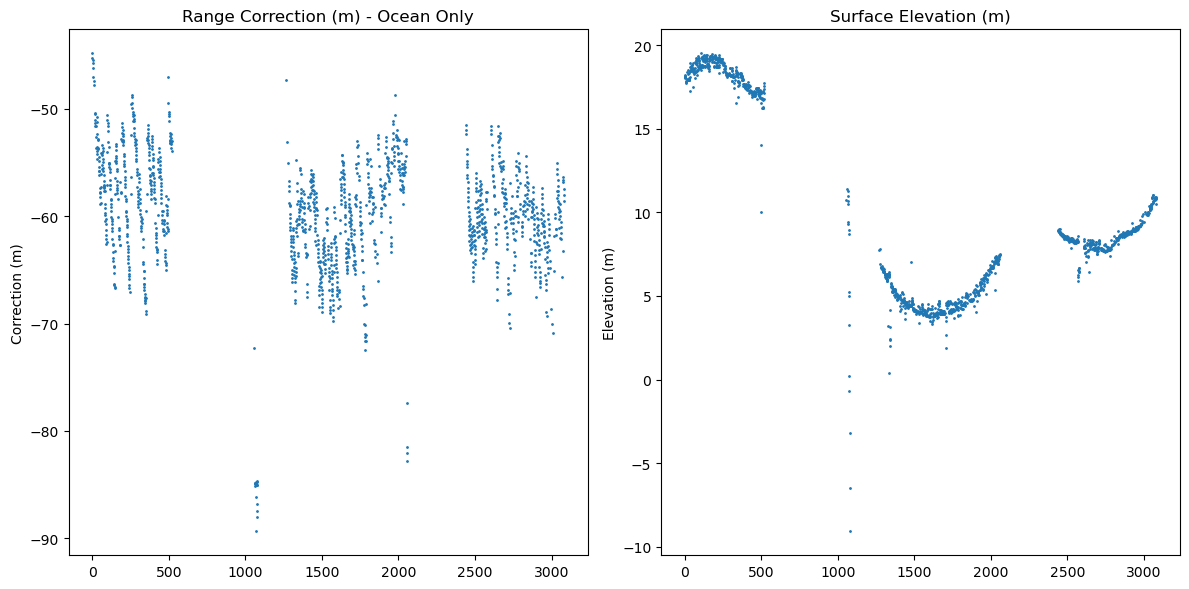

In [49]:
# 绘图时，可以直接用 .dropna() 滤除 NaN 进行绘图，完全不影响你的原始 DataFrame
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# 画图时自动忽略 NaN
plt.plot(df_region['range_correction'].dropna(), marker='.', linestyle='none', markersize=2)
plt.title('Range Correction (m) - Ocean Only')
plt.ylabel('Correction (m)')

plt.subplot(1, 2, 2)
plt.plot(df_region['elevation'].dropna(), marker='.', linestyle='none', markersize=2)
plt.title('Surface Elevation (m)')
plt.ylabel('Elevation (m)')

plt.tight_layout()
plt.show()

In [ ]:

# # 3. 仅提取海洋对应的波形去跑算法 (此时它们是短数组)
# valid_waveforms = waveform_region[ocean_mask]
# valid_window_del = window_del_region[ocean_mask]

# # 去跑重追踪算法
# valid_range_TFMRA = retrack_diffuse_waveform_tilling(valid_waveforms, mode=mode)
# valid_range_final = compute_final_range(valid_range_TFMRA, valid_window_del)
# valid_range_window_del = valid_window_del * c / 2

# # 4. 【奇迹发生的一步：无缝写回原表】
# # 先在 DataFrame 里新建这三列，并全填上 NaN
# df_region['range_correction'] = np.nan
# df_region['range_final'] = np.nan
# df_region['range_window_del'] = np.nan

# # 使用 .loc 将算好的短数组精准塞进 ocean_mask 为 True 的行里！
# # Pandas 会自动按条件对齐，陆地所在的行依然是 NaN，完美的保留了完整的 L1 索引！
# df_region.loc[ocean_mask, 'range_correction'] = valid_range_TFMRA
# df_region.loc[ocean_mask, 'range_final'] = valid_range_final
# df_region.loc[ocean_mask, 'range_window_del'] = valid_range_window_del

# # ==================== 绘图验证 ====================
# plt.figure(figsize=(12, 6))

# plt.subplot(1, 2, 1)
# plt.plot(range_TFMRA, marker='.', linestyle='none', markersize=2)
# plt.title('Range Correction (m)')
# plt.xlabel('Measurement Index')
# plt.ylabel('Correction (m)')

# plt.subplot(1, 2, 2)
# plt.plot(range_final, marker='.', linestyle='none', markersize=2)
# plt.title('Final Range (m)')
# plt.xlabel('Measurement Index')
# plt.ylabel('Absolute Range (m)')

# plt.tight_layout()
# plt.show()

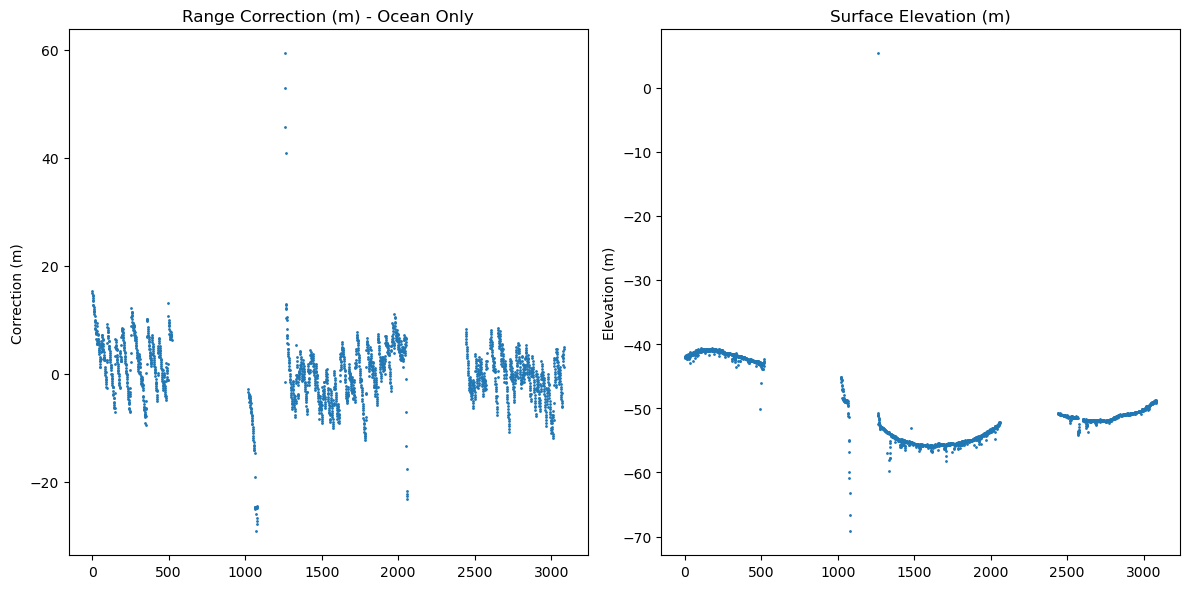

In [ ]:
# # ==================== 计算最终高程 ====================
# # 只有被赋了值的海洋行会算出高程，陆地行因为是 NaN，算出来的高程也是 NaN
# df_region['elevation'] = df_region['alt'] - df_region['range_final']

# # 绘图时，可以直接用 .dropna() 滤除 NaN 进行绘图，完全不影响你的原始 DataFrame
# plt.figure(figsize=(12, 6))

# plt.subplot(1, 2, 1)
# # 画图时自动忽略 NaN
# plt.plot(df_region['range_correction'].dropna(), marker='.', linestyle='none', markersize=2)
# plt.title('Range Correction (m) - Ocean Only')
# plt.ylabel('Correction (m)')

# plt.subplot(1, 2, 2)
# plt.plot(df_region['elevation'].dropna(), marker='.', linestyle='none', markersize=2)
# plt.title('Surface Elevation (m)')
# plt.ylabel('Elevation (m)')

# plt.tight_layout()
# plt.show()

### correction data read

In [50]:
# Read time and waveform data (automatically mapped)
time_20_ku = ds['time_20_ku'].values
time_cor_01= ds['time_cor_01'].values

#iono_cor_gim_01 = ds['iono_cor_gim_01'].values #* 0.001
iono_cor_01 = ds['iono_cor_01'].values #* 0.001
mod_dry_tropo_cor_01 = ds['mod_dry_tropo_cor_01'].values # * 0.001  # 应用缩放因子
mod_wet_tropo_cor_01= ds['mod_wet_tropo_cor_01'].values #* 0.001
inv_bar_cor_01 = ds['inv_bar_cor_01'].values #* 0.001
#hf_fluct_total_cor_01 = ds['hf_fluct_total_cor_01'].values #* 0.001

ocean_tide_01 = ds['ocean_tide_01'].values # elastic ocean tide
ocean_tide_eq_01 = ds['ocean_tide_eq_01'].values #long period ocean tide
load_tide_01 = ds['load_tide_01'].values #ocean loading tide
solid_earth_tide_01 = ds['solid_earth_tide_01'].values #* 0.001
pole_tide_01 = ds['pole_tide_01'].values #geocentric polar tide

flag_cor_status_01 = ds['flag_cor_status_01'].values
flag_cor_err_01 = ds['flag_cor_err_01'].values


# 读取 20Hz 维度大小
N_20 = len(time_20_ku)

# 获取 1Hz 校正值的索引
ind_first_meas = ds["ind_first_meas_20hz_01"].values.astype(int)

# 需要扩展的校正值列表
correction_vars = [
    'mod_dry_tropo_cor_01', 'mod_wet_tropo_cor_01', 'inv_bar_cor_01', 
    'iono_cor_01', 
    'ocean_tide_01', 'ocean_tide_eq_01', 'load_tide_01', 
    'solid_earth_tide_01', 'pole_tide_01'
]

# 初始化存储扩展后的校正数据
corrections_20hz = {var: np.full(N_20, np.nan) for var in correction_vars}

# 遍历 1Hz 索引并扩展校正数据
for i in range(len(ind_first_meas)):
    start_idx = ind_first_meas[i]
    end_idx = min(start_idx + 20, N_20)  # 确保索引不超出范围

    for var in correction_vars:
        corrections_20hz[var][start_idx:end_idx] = ds[var].values[i]  # 复制 1Hz 值到 20Hz

# 创建 DataFrame，存储扩展后的校正数据
df_corrections_20hz = pd.DataFrame(corrections_20hz)
df_corrections_20hz["time_20_ku"] = time_20_ku

# 打印检查
print(df_corrections_20hz.head())

   mod_dry_tropo_cor_01  mod_wet_tropo_cor_01  inv_bar_cor_01  iono_cor_01  \
0                 -2.35                 -0.01          -0.229       -0.017   
1                 -2.35                 -0.01          -0.229       -0.017   
2                 -2.35                 -0.01          -0.229       -0.017   
3                 -2.35                 -0.01          -0.229       -0.017   
4                 -2.35                 -0.01          -0.229       -0.017   

   ocean_tide_01  ocean_tide_eq_01  load_tide_01  solid_earth_tide_01  \
0         -0.091             0.016         0.002                0.035   
1         -0.091             0.016         0.002                0.035   
2         -0.091             0.016         0.002                0.035   
3         -0.091             0.016         0.002                0.035   
4         -0.091             0.016         0.002                0.035   

   pole_tide_01                    time_20_ku  
0        -0.001 2022-03-23 22:48:04.90667200

In [51]:
corrections_sum = sum(df_corrections_20hz[var] for var in correction_vars)
df['corrections_sum'] = corrections_sum

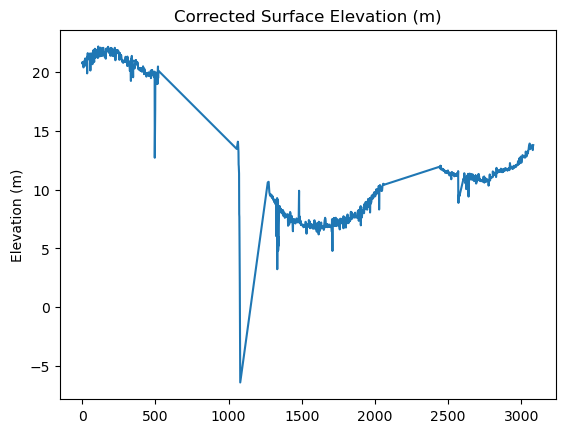

In [52]:
df_region['C_G'] = df['corrections_sum']
df_region['R0_True'] = df_region['range_final'] + df_region['C_G']

# 最最终的高程！
df_region['elevation_corrected'] = df_region['alt'] - df_region['R0_True']
plt.plot(df_region['elevation_corrected'].dropna())
plt.title('Corrected Surface Elevation (m)')
plt.ylabel('Elevation (m)') 
plt.show()


In [150]:
print(df.head())

                     time_20_ku                   utc_time         alt  \
0 2022-03-23 22:48:04.906672000 2022-03-23 22:48:04.906672  731055.842   
1 2022-03-23 22:48:04.951907072 2022-03-23 22:48:04.951907  731055.524   
2 2022-03-23 22:48:04.997142016 2022-03-23 22:48:04.997142  731055.206   
3 2022-03-23 22:48:05.042376064 2022-03-23 22:48:05.042376  731054.888   
4 2022-03-23 22:48:05.087609984 2022-03-23 22:48:05.087610  731054.570   

   noise_power_real   std    pp     k        lat        lon  surf_type  \
0           -183.37  6.19  2.44 -1.27  84.178388 -59.764860        0.0   
1           -183.38  6.04  2.44 -1.35  84.175831 -59.774344        0.0   
2           -183.02  6.19  2.41 -1.45  84.173273 -59.783821        0.0   
3           -183.41  6.70  2.25 -1.44  84.170716 -59.793289        0.0   
4           -183.70  6.63  1.79 -1.16  84.168159 -59.802750        0.0   

                 window_del  window_del_seconds type  corrections_sum  
0 0 days 00:00:00.004877258           

Region boundary: lon(-131.9280393336191, -124.14615113942654), lat(73.92436198306802, 77.35724703602278)

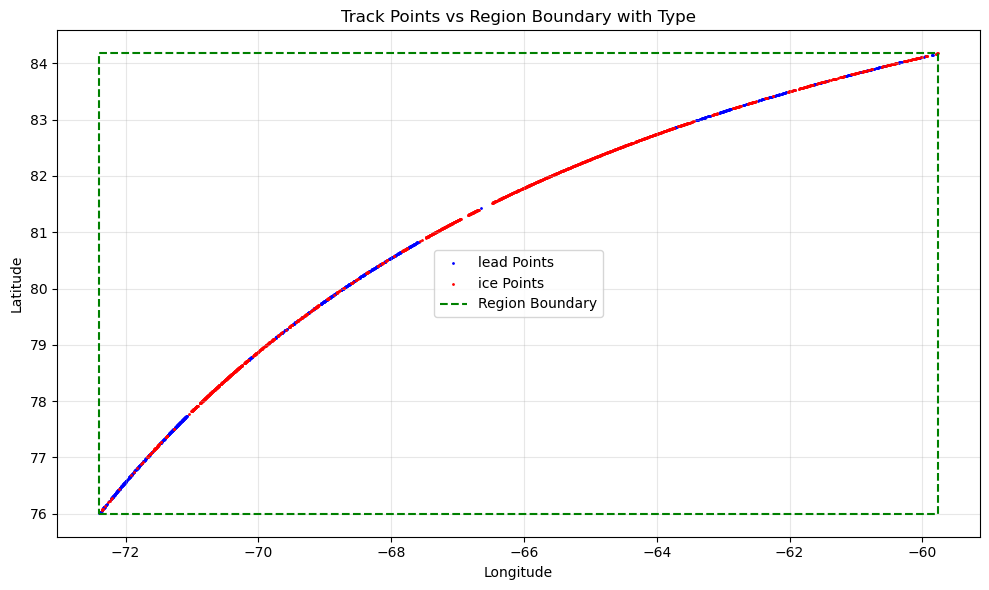

In [53]:
import matplotlib.pyplot as plt
# 绘制轨迹点和区域边界
plt.figure(figsize=(10, 6))

# 绘制轨迹点，按 type 类型区分颜色
for t, color in [('lead', 'blue'), ('ice', 'red')]:
    mask = df['type'] == t
    plt.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'], s=1, label=f'{t} Points', color=color)

# 绘制区域边界
plt.plot(
    [min_lon, max_lon, max_lon, min_lon, min_lon],
    [min_lat, min_lat, max_lat, max_lat, min_lat],
    color='green', linestyle='--', label='Region Boundary'
)

# 图形设置
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Track Points vs Region Boundary with Type')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [54]:
df_L1 = df_region.copy()

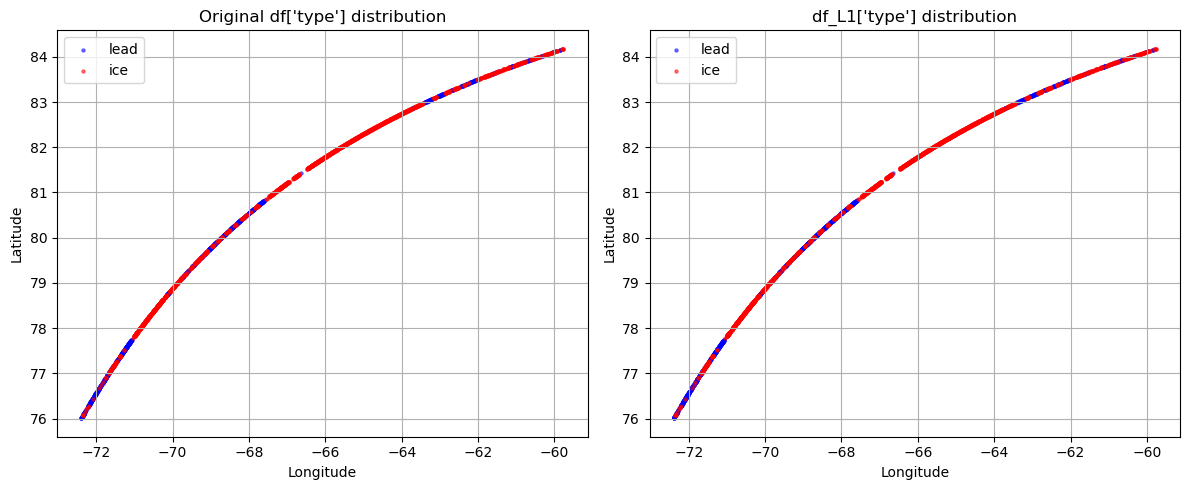

In [55]:
import matplotlib.pyplot as plt

# 原始数据 df 的分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for t, color in [('lead', 'blue'), ('ice', 'red')]:
    mask = df['type'] == t
    plt.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'], label=t, s=5, alpha=0.5, c=color)
plt.title("Original df['type'] distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

# 筛选后 df_L1 的分布
plt.subplot(1, 2, 2)
for t, color in [('lead', 'blue'), ('ice', 'red')]:
    mask = df_L1['type'] == t
    plt.scatter(df_L1.loc[mask, 'lon'], df_L1.loc[mask, 'lat'], label=t, s=5, alpha=0.5, c=color)
plt.title("df_L1['type'] distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [56]:
print("df_L1['type'] value counts:")
print(df_L1['type'].value_counts(dropna=False))


df_L1['type'] value counts:
ice        1491
lead        843
unknown     750
Name: type, dtype: int64


In [59]:
from scipy.interpolate import griddata

mss_file = r"E:\Project_2024\CryoSat-2 L1\DTU21MSS_1min_WGS84.nc"
ds_mss = xr.open_dataset(mss_file)

# 转换经度范围 [0, 360] -> [-180, 180]
lon_mss = ds_mss['lon'].values
lat_mss = ds_mss['lat'].values
lon_mss[lon_mss > 180] -= 360

# meshgrid 成二维坐标点（MSS是规则网格）
lon_mss_grid, lat_mss_grid = np.meshgrid(lon_mss, lat_mss)
mss_data = ds_mss['mean_sea_surf_sol2'].values  # shape = (lat, lon)


# 从 df_L1 中获取经纬度边界
# updates: 2025/5/7 将df_L1先按照region筛选裁剪
min_lon, max_lon = df_L1['lon'].min(), df_L1['lon'].max()
min_lat, max_lat = df_L1['lat'].min(), df_L1['lat'].max()

print(f"自动识别裁剪范围:lon({min_lon:.2f}, {max_lon:.2f}), lat({min_lat:.2f}, {max_lat:.2f})")

# 裁剪 MSS 数据（使用更安全的 where）
mss_clipped = ds_mss.where(
    (ds_mss.lon >= min_lon) & (ds_mss.lon <= max_lon) &
    (ds_mss.lat >= min_lat) & (ds_mss.lat <= max_lat),
    drop=True
)
lon_grid, lat_grid = np.meshgrid(mss_clipped.lon.values, mss_clipped.lat.values)
print(f"MSS 裁剪后尺寸:lon={mss_clipped.sizes['lon']}, lat={mss_clipped.sizes['lat']}")

# Flatten the 2D grid for use in griddata
mss_interp = griddata(
    (lon_grid.flatten(), lat_grid.flatten()),
    mss_clipped.mean_sea_surf_sol2.values.flatten(),
    (df_L1['lon'], df_L1['lat']),
    method='linear'
)

# 8. 将插值结果添加回原数据
df_L1['mss_interp'] = (mss_interp)

print("MSS 数据处理完成，并已插值到轨迹点！")

自动识别裁剪范围:lon(-72.40, -59.76), lat(76.00, 84.18)
MSS 裁剪后尺寸:lon=758, lat=491
MSS 数据处理完成，并已插值到轨迹点！


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


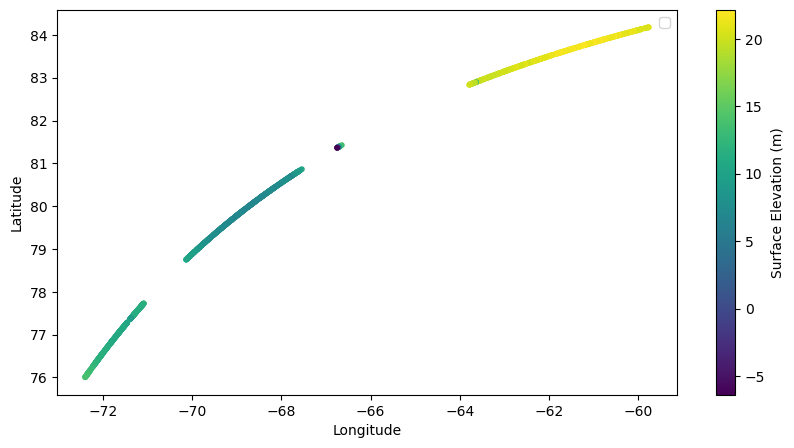

In [60]:
h_surface = df_L1['alt'] - df_L1['range_final'] - df_L1['corrections_sum']

df_L1['h_surface'] = h_surface
df_L1['corrections_sum'] = corrections_sum 
df_L1['h_surface_no_TFMRA'] = df_L1['alt'] - df_L1['range_window_del'] + df_L1['corrections_sum']
# 5. 可视化地表高程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_L1["lon"], df_L1["lat"], c=h_surface, cmap="viridis", s=10)
plt.colorbar(sc, label="Surface Elevation (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()
plt.show()

In [61]:
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

# === Step 0: 初始化与异常值剔除 ===
# 确保 type 字段中标记了 lead 点
lead_mask = (df_L1['type'] == 'lead')

# 计算初始的 SLA_raw
df_L1['SLA_raw'] = np.nan
df_L1.loc[lead_mask, 'SLA_raw'] = df_L1.loc[lead_mask, 'h_surface'] - df_L1.loc[lead_mask, 'mss_interp']

# 【核心修正 1】：剔除 SLA_raw 超过 ±3m 的极值点 (Tilling 2018 要求)
valid_lead_mask = lead_mask & (df_L1['SLA_raw'] >= -3.0) & (df_L1['SLA_raw'] <= 3.0)

# 提取经过 ±3m 过滤后的有效 lead 点索引和 SLA_raw 数值
valid_lead_indices = df_L1.index[valid_lead_mask].to_numpy()
valid_SLA_raw_values = df_L1.loc[valid_lead_mask, 'SLA_raw'].to_numpy()

print(f"有效的 Lead 点数量 (剔除 ±3m 异常值后): {len(valid_SLA_raw_values)}")

# 如果有效的水道点太少（例如少于2个），无法进行插值
if len(valid_SLA_raw_values) > 1:
    
    # === Step 1: 对有效的 SLA_raw 进行平滑 ===
    # 论文中是取两侧 100km（总共 200km）内的数据进行拟合。
    # 我们用 200km 的窗口进行 rolling mean 作为近似
    window_200km_bins = int(200000 / 380)  # 假设 sampling 约为 380m

    SLA_raw_series = pd.Series(valid_SLA_raw_values, index=valid_lead_indices)
    
    # 使用 200km 窗口平滑，min_periods=1 保证只要窗口内有 lead 就能计算
    SLA_smoothed_raw = SLA_raw_series.rolling(window=window_200km_bins, center=True, min_periods=1).mean()

    # === Step 2: 线性插值到全轨迹 ===
    # 【核心修正 2】：bounds_error=False 和 fill_value=np.nan 保证了不进行外推！
    # 这严格满足了论文中 "浮冰两侧必须至少各有一个水道" 的要求。超出两端 lead 的点会保持为 NaN。
    interp_func = interp1d(
        SLA_smoothed_raw.index, 
        SLA_smoothed_raw.values, 
        kind='linear', 
        bounds_error=False, 
        fill_value=np.nan  
    )
    
    # 将插值结果赋给全轨迹
    df_L1['SLA_interp'] = interp_func(df_L1.index)
    
    # 【核心修正 3】：直接使用插值结果，移除违规的 ffill/bfill 和第二次 uniform_filter1d 滤波
    df_L1['SLA_final'] = df_L1['SLA_interp']

else:
    print("警告：没有足够的 lead 点进行插值！")
    df_L1['SLA_final'] = np.nan

# 最终你的 SLA 以及可用于计算 Freeboard 的列
df_L1['SLA'] = df_L1['SLA_final']

print(f"成功插值的点数（这些点可以用来算干舷）: {df_L1['SLA'].notna().sum()}")

有效的 Lead 点数量 (剔除 ±3m 异常值后): 823
成功插值的点数（这些点可以用来算干舷）: 3071


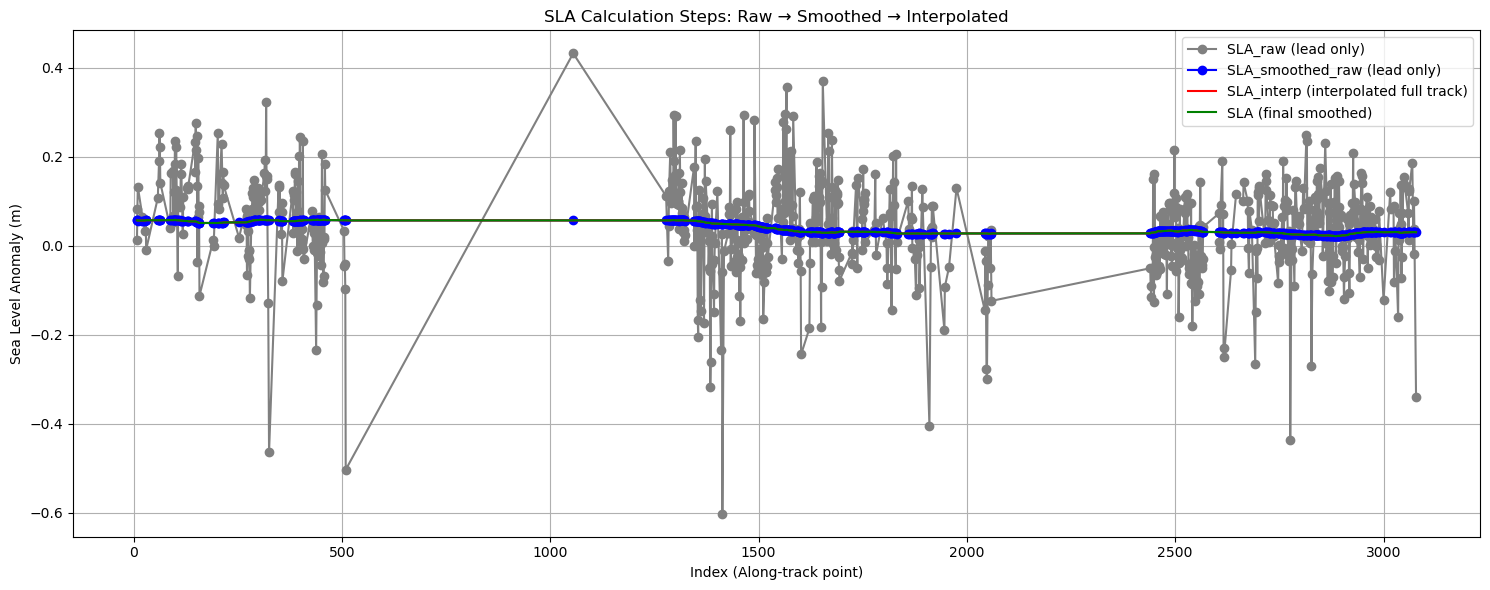

In [62]:
import matplotlib.pyplot as plt

# 假设你已经有这些变量：
# - df_L1（包含最终插值得到的 df_L1['SLA']）
# - SLA_raw_series（原始的 SLA_raw，pandas Series，索引是 lead_indices）
# - SLA_smoothed_raw（在 lead 上平滑后的值，Series，同样索引是 lead_indices）

plt.figure(figsize=(15, 6))

# Step 1: 原始 SLA_raw
plt.plot(SLA_raw_series.index, SLA_raw_series.values, 'o-', label='SLA_raw (lead only)', color='gray')

# Step 2: 平滑后 SLA
plt.plot(SLA_smoothed_raw.index, SLA_smoothed_raw.values, 'o-', label='SLA_smoothed_raw (lead only)', color='blue')

# Step 3: 插值得到的连续 SLA（整条轨迹）
plt.plot(df_L1.index, df_L1['SLA_interp'], '-', label='SLA_interp (interpolated full track)', color='red')

# Step 4: 最终平滑后的 SLA
plt.plot(df_L1.index, df_L1['SLA'], '-', label='SLA (final smoothed)', color='green')

plt.xlabel('Index (Along-track point)')
plt.ylabel('Sea Level Anomaly (m)')
plt.title('SLA Calculation Steps: Raw → Smoothed → Interpolated')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

# === 优化 1：使用 cKDTree 毫秒级计算到最近 Lead 的距离 ===
R = 6371000.0  # 地球半径（米）

# 将经纬度转为弧度 (cKDTree 需要)
all_coords_rad = np.radians(df_L1[['lat', 'lon']].to_numpy())
lead_coords_rad = np.radians(df_L1.loc[lead_mask, ['lat', 'lon']].to_numpy())

if len(lead_coords_rad) > 0:
    # 构建基于 Haversine 距离的 KDTree
    tree = cKDTree(lead_coords_rad)
    
    # query(..., k=1) 会返回到最近的一个 lead 的距离和索引
    dist_rad, _ = tree.query(all_coords_rad, k=1)
    
    # 乘以地球半径转换为米
    df_L1['dist_to_lead'] = dist_rad * R
else:
    df_L1['dist_to_lead'] = np.inf

print("距离计算完成！")
print(df_L1['dist_to_lead'].describe())

# === 修正 2：将距离阈值改为文献要求的 100km ===
# Tilling 2018: extending 100 km either side
df_L1.loc[df_L1['dist_to_lead'] > 100000, 'SLA'] = np.nan

# === 步骤 3：计算初始雷达干舷 (Radar Freeboard) ===
ice_mask = (df_L1['type'] == 'ice')
df_L1['radar_freeboard'] = np.nan

# 计算公式：浮冰高程 - (MSS + SLA)
df_L1.loc[ice_mask, 'radar_freeboard'] = df_L1.loc[ice_mask, 'h_surface'] - (
    df_L1.loc[ice_mask, 'mss_interp'] + df_L1.loc[ice_mask, 'SLA']
)

print("\n初始雷达干舷 (fi) 计算完成：")
print(df_L1['radar_freeboard'].describe())

# ==========================================
# ⚠️ 注意：此处已删除原代码中 -0.25 到 2.25 的过滤！
# 根据 Tilling (2018)，下一步你应该：
# 1. 匹配雪深数据 (hs)
# 2. 计算校正干舷: df_L1['corrected_freeboard'] = df_L1['radar_freeboard'] + 0.25 * hs
# 3. 对 corrected_freeboard 应用 -0.3m 到 3.0m 的过滤掩膜
# ==========================================

距离计算完成！
count      3084.000000
mean      23926.820235
std       41090.424216
min           0.000000
25%           0.000000
50%        2398.018513
75%       32074.432417
max      180882.351447
Name: dist_to_lead, dtype: float64

初始雷达干舷 (fi) 计算完成：
count    545.000000
mean       0.045117
std        1.641646
min      -19.432323
25%        0.190246
50%        0.393191
75%        0.513759
max        2.713203
Name: radar_freeboard, dtype: float64


In [75]:
from geopy.distance import geodesic
distance_km = [0]

for i in range(1, len(df_L1)):
    coord1 = (df_L1['lat'].iloc[i-1], df_L1['lon'].iloc[i-1])
    coord2 = (df_L1['lat'].iloc[i], df_L1['lon'].iloc[i])
    d = geodesic(coord1, coord2).km
    distance_km.append(distance_km[-1] + d)

df_L1['distance'] = distance_km

## 厚度计算

In [117]:
import xarray as xr
from scipy.interpolate import RegularGridInterpolator

# 1. 读取你下载的那个月的合并雪深产品
ds_snow = xr.open_dataset(r"D:\S1_CS2_data\awi_snow_merged\awi-siral-l4-snow_on_seaice-monthly_warren_amsr2_clim-01-fv1p0.nc")
print(ds_snow.head())

<xarray.Dataset>
Dimensions:                                          (lat: 5, lon: 5)
Dimensions without coordinates: lat, lon
Data variables: (12/16)
    longitude                                        (lat, lon) float64 ...
    latitude                                         (lat, lon) float64 ...
    region_id                                        (lat, lon) float64 ...
    w99_snow_depth                                   (lat, lon) float64 ...
    w99_snow_depth_uncertainty                       (lat, lon) float64 ...
    w99_snow_density                                 (lat, lon) float64 ...
    ...                                               ...
    amsr2_snow_depth_composite_uncertainty           (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered              (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered_uncertainty  (lat, lon) float64 ...
    w99_weight                                       (lat, lon) float64 ...
    merged_snow_depth         

In [118]:
# 查看整个数据集的维度、坐标和变量
print(ds_snow)

# 如果在 Jupyter Notebook 中，直接输入变量名查看交互式视图
ds_snow


<xarray.Dataset>
Dimensions:                                          (lat: 1792, lon: 1216)
Dimensions without coordinates: lat, lon
Data variables: (12/16)
    longitude                                        (lat, lon) float64 ...
    latitude                                         (lat, lon) float64 ...
    region_id                                        (lat, lon) float64 ...
    w99_snow_depth                                   (lat, lon) float64 ...
    w99_snow_depth_uncertainty                       (lat, lon) float64 ...
    w99_snow_density                                 (lat, lon) float64 ...
    ...                                               ...
    amsr2_snow_depth_composite_uncertainty           (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered              (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered_uncertainty  (lat, lon) float64 ...
    w99_weight                                       (lat, lon) float64 ...
    merged_snow_depth   

<xarray.Dataset>
Dimensions:                                          (lat: 1792, lon: 1216)
Dimensions without coordinates: lat, lon
Data variables: (12/16)
    longitude                                        (lat, lon) float64 ...
    latitude                                         (lat, lon) float64 ...
    region_id                                        (lat, lon) float64 ...
    w99_snow_depth                                   (lat, lon) float64 ...
    w99_snow_depth_uncertainty                       (lat, lon) float64 ...
    w99_snow_density                                 (lat, lon) float64 ...
    ...                                               ...
    amsr2_snow_depth_composite_uncertainty           (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered              (lat, lon) float64 ...
    amsr2_snow_depth_composite_filtered_uncertainty  (lat, lon) float64 ...
    w99_weight                                       (lat, lon) float64 ...
    merged_snow_depth                                (lat, lon) float64 ...
    merged_snow_depth_uncertainty                    (lat, lon) float64 ...
Attributes: (12/24)
    title:                   Monthly merged snow on sea ice climatology based...
    institution:             Alfred Wegener Institute Helmholtz Centre for Po...
    source:                  Warren99 snow depth climatology (Warren et al., ...
    history:                 created
    references:              
    tracking_id:             b8f67b3b-6312-43f8-bfa3-655c7ddf9d83
    ...                      ...
    contributor_name:        Institute Of Environmental Physics (IUP)
    contributor_role:        Generation of snow depth from AMSR2
    project:                 AWI Sea Ice Radar Altimetry (SIRAL)
    spatial_resolution:      6.25 km grid spacing
    proj4str:                +a=6378273 +b=6356889.449 +lat_ts=70 +lon_0=-45 ...
    time_coverage_duration:  P1M

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import os

# ==========================================
# 步骤 1：准备时间戳并预留海冰类型接口 (Placeholder)
# ==========================================
# 确保 utc_time 是 datetime 类型
df_L1['utc_time'] = pd.to_datetime(df_L1['utc_time'])
df_L1['month'] = df_L1['utc_time'].dt.month

# 🚨 【接口预留区】：目前假定全部为一年冰 (FYI)
# 未来如果有 OSI SAF 数据，只需在这里把真实的多年冰比例赋给 f_myi
# 100% 一年冰 -> f_myi = 0.0; 100% 多年冰 -> f_myi = 1.0
df_L1['f_myi'] = 0.0  

# 初始化提取列，确保它们在 DataFrame 中存在
df_L1['merged_sd_raw'] = np.nan
df_L1['w99_weight'] = np.nan
df_L1['hs'] = np.nan

unique_months = df_L1['month'].dropna().unique()

# ==========================================
# 步骤 2：加载对应月份的雪深 NC 文件并进行空间插值
# ==========================================
# ⚠️ 修改这里为你实际存放雪深数据的文件夹路径
snow_dir = r"D:\S1_CS2_data\awi_snow_merged" 

# for month in unique_months:
#     # 按照你截图中的文件名规则动态拼接
#     snow_file = os.path.join(snow_dir, f"awi-siral-l4-snow_on_seaice-monthly_warren_amsr2_clim-{int(month):02d}-fv1p0.nc")
    
#     if not os.path.exists(snow_file):
#         print(f"⚠️ 警告：找不到文件 {snow_file}，跳过 {month} 月数据。")
#         continue
        
#     ## 1. 提取原始网格坐标和数据 (不碰 xarray 的内部坐标，避免破坏单调性)
#     lon_snow = ds_snow['lon'].values
#     lat_snow = ds_snow['lat'].values
    
#     lon_grid, lat_grid = np.meshgrid(lon_snow, lat_snow)
#     snow_grid = ds_snow['merged_snow_depth'].values
#     w_var_name = 'w99_weight' 
#     weight_grid = ds_snow[w_var_name].values if w_var_name in ds_snow.data_vars else np.ones_like(snow_grid)
    
#     # 2. 在 NumPy 层面强制把所有经度统一到 [-180, 180] 范围
#     lon_grid_180 = ((lon_grid + 180) % 360) - 180
    
#     # 3. 提取有效数据点（剔除海陆掩膜产生的 NaN），这会让 griddata 速度起飞
#     valid_mask = ~np.isnan(snow_grid)
#     points_valid = (lon_grid_180[valid_mask], lat_grid[valid_mask])
#     snow_valid = snow_grid[valid_mask]
#     weight_valid = weight_grid[valid_mask]
    
#     if len(snow_valid) == 0:
#         print(f"⚠️ {month:02d}月网格内无有效雪深数据！")
#         continue

#     # 4. 获取当前月份 L1 轨迹点，也强制统一到 [-180, 180] 
#     month_mask = (df_L1['month'] == month)
#     pts_lon_180 = ((df_L1.loc[month_mask, 'lon'].values + 180) % 360) - 180
#     pts_lat = df_L1.loc[month_mask, 'lat'].values
#     target_pts = (pts_lon_180, pts_lat)

#     # 5. 【双重保险插值法】先用 linear 保证精度
#     interp_sd = griddata(points_valid, snow_valid, target_pts, method='linear')
#     interp_w = griddata(points_valid, weight_valid, target_pts, method='linear')
    
#     # 6. 【防 NaN 补丁】查找 linear 越界产生的 NaN，用 nearest 补全
#     nan_mask = np.isnan(interp_sd)
#     if nan_mask.any():
#         print(f"   -> 发现 {nan_mask.sum()} 个越界点，正在使用 nearest 补全...")
#         # 取出这些出界的经纬度
#         target_pts_nan = (pts_lon_180[nan_mask], pts_lat[nan_mask])
        
#         # 用 nearest 重新插这些越界点
#         interp_sd[nan_mask] = griddata(points_valid, snow_valid, target_pts_nan, method='nearest')
#         interp_w[nan_mask] = griddata(points_valid, weight_valid, target_pts_nan, method='nearest')

#     # 7. 写回原始 DataFrame
#     df_L1.loc[month_mask, 'merged_sd_raw'] = interp_sd
#     df_L1.loc[month_mask, 'w99_weight'] = interp_w
    
#     print(f"✅ {month:02d}月雪深数据处理完成，已完美插值到轨迹点！")


✅ 03月 - 严格插值完成！获取到 0 个真实的雪深物理值。


In [135]:

for month in unique_months:
    # 按照你截图中的文件名规则动态拼接
    snow_file = os.path.join(snow_dir, f"awi-siral-l4-snow_on_seaice-monthly_warren_amsr2_clim-{int(month):02d}-fv1p0.nc")
    
    if not os.path.exists(snow_file):
        print(f"⚠️ 警告：找不到文件 {snow_file}，跳过 {month} 月数据。")
        continue
        
    ## 1. 提取原始网格坐标和数据 (不碰 xarray 的内部坐标，避免破坏单调性)
    lon_snow = ds_snow['lon'].values
    lat_snow = ds_snow['lat'].values
    
    lon_grid, lat_grid = np.meshgrid(lon_snow, lat_snow)
    snow_grid = ds_snow['merged_snow_depth'].values
    w_var_name = 'w99_weight' 
    weight_grid = ds_snow[w_var_name].values if w_var_name in ds_snow.data_vars else np.ones_like(snow_grid)
    
    # 2. 在 NumPy 层面强制把所有经度统一到 [-180, 180] 范围
    lon_grid_180 = ((lon_grid + 180) % 360) - 180
    
    # 3. 提取有效数据点（剔除海陆掩膜产生的 NaN），这会让 griddata 速度起飞
    valid_mask = ~np.isnan(snow_grid)
    points_valid = (lon_grid_180[valid_mask], lat_grid[valid_mask])
    snow_valid = snow_grid[valid_mask]
    weight_valid = weight_grid[valid_mask]
    
    if len(snow_valid) == 0:
        print(f"⚠️ {month:02d}月网格内无有效雪深数据！")
        continue

    # 4. 获取当前月份 L1 轨迹点，也强制统一到 [-180, 180] 
    month_mask = (df_L1['month'] == month)
    pts_lon_180 = ((df_L1.loc[month_mask, 'lon'].values + 180) % 360) - 180
    pts_lat = df_L1.loc[month_mask, 'lat'].values
    target_pts = (pts_lon_180, pts_lat)

    # 5. 【双重保险插值法】先用 linear 保证精度
    interp_sd = griddata(points_valid, snow_valid, target_pts, method='linear')
    interp_w = griddata(points_valid, weight_valid, target_pts, method='linear')
    
    # 6. 【防 NaN 补丁】查找 linear 越界产生的 NaN，用 nearest 补全
    nan_mask = np.isnan(interp_sd)
    if nan_mask.any():
        print(f"   -> 发现 {nan_mask.sum()} 个越界点，正在使用 nearest 补全...")
        # 取出这些出界的经纬度
        target_pts_nan = (pts_lon_180[nan_mask], pts_lat[nan_mask])
        
        # 用 nearest 重新插这些越界点
        interp_sd[nan_mask] = griddata(points_valid, snow_valid, target_pts_nan, method='nearest')
        interp_w[nan_mask] = griddata(points_valid, weight_valid, target_pts_nan, method='nearest')

    # 7. 写回原始 DataFrame
    df_L1.loc[month_mask, 'merged_sd_raw'] = interp_sd
    df_L1.loc[month_mask, 'w99_weight'] = interp_w
    
    print(f"✅ {month:02d}月雪深数据处理完成，已插值到轨迹点！")

✅ 03月雪深数据处理完成，已完美插值到轨迹点！


In [137]:
print(df_L1["merged_sd_raw"].describe())

count    3084.000000
mean        0.000911
std         0.000167
min         0.000632
25%         0.000766
50%         0.000905
75%         0.001053
max         0.001218
Name: merged_sd_raw, dtype: float64


In [138]:

# ==========================================
# 步骤 3：应用 ATBD 规则进行海冰类型雪深修正
# ==========================================
c_fyi = 0.5  # 一年冰在 W99 中的缩放比例 (即减半)

# 计算缩放系数 c (ATBD 公式: c = (1 - f_myi) * c_fyi * w)
df_L1['c_factor'] = (1 - df_L1['f_myi']) * c_fyi * df_L1['w99_weight']

# 计算最终用于厚度反演的雪深 (hs)
# ATBD 截图中的修正公式: sd = sd_merged - c * sd_merged
df_L1['hs'] = df_L1['merged_sd_raw'] - (df_L1['c_factor'] * df_L1['merged_sd_raw'])

print("\n最终插值并修正后的雪深 (hs) 统计：")
print(df_L1['hs'].describe())

# ==========================================
# 步骤 4：计算校正干舷 (Corrected Freeboard) 并执行终极过滤
# ==========================================
# 补偿光速在雪中变慢的延迟
df_L1['corrected_freeboard'] = df_L1['radar_freeboard'] + 0.25 * df_L1['hs']

# Tilling et al. (2018) 终极过滤：把不在 -0.3m 到 3.0m 范围内的异常值全部剔除 [cite: 540]！
valid_fc_mask = (df_L1['corrected_freeboard'] >= -0.3) & (df_L1['corrected_freeboard'] <= 3.0)

# 把不在范围内的极值设为 NaN，无损保留所有索引
df_L1.loc[~valid_fc_mask, 'corrected_freeboard'] = np.nan

print("\n过滤后的校正干舷 (fc) 统计：")
print(df_L1['corrected_freeboard'].describe())



最终插值并修正后的雪深 (hs) 统计：
count    3084.000000
mean        0.000911
std         0.000167
min         0.000632
25%         0.000766
50%         0.000905
75%         0.001053
max         0.001218
Name: hs, dtype: float64

过滤后的校正干舷 (fc) 统计：
count    479.000000
mean       0.399117
std        0.240719
min       -0.293990
25%        0.293712
50%        0.415767
75%        0.528124
max        2.713432
Name: corrected_freeboard, dtype: float64


In [139]:

# ==========================================
# 步骤 5：终极奥义 -> 流体静力学平衡计算海冰厚度 [cite: 546]
# ==========================================
# 设置密度常量 (kg/m^3)
rho_w = 1023.9
rho_s = 324.0  # 假设春季雪密度参考值

# 🚨 【接口预留区】：根据 f_myi 动态赋予海冰密度
# FYI 密度 = 916.7; MYI 密度 = 882.0
# 由于前面设了 f_myi = 0，这里所有点的 rho_i 会自动变成 916.7
df_L1['rho_i'] = df_L1['f_myi'] * 882.0 + (1 - df_L1['f_myi']) * 916.7

# 计算冰厚 (Sea Ice Thickness) [cite: 546]
df_L1['sea_ice_thickness'] = (
    (df_L1['corrected_freeboard'] * rho_w + df_L1['hs'] * rho_s) / 
    (rho_w - df_L1['rho_i'])
)

print("\n🎉 最终成果！海冰厚度 (Sea Ice Thickness) 统计：")
print(df_L1['sea_ice_thickness'].dropna().describe())


🎉 最终成果！海冰厚度 (Sea Ice Thickness) 统计：
count    479.000000
mean       3.815067
std        2.299236
min       -2.805345
25%        2.808062
50%        3.973818
75%        5.047748
max       25.919589
Name: sea_ice_thickness, dtype: float64


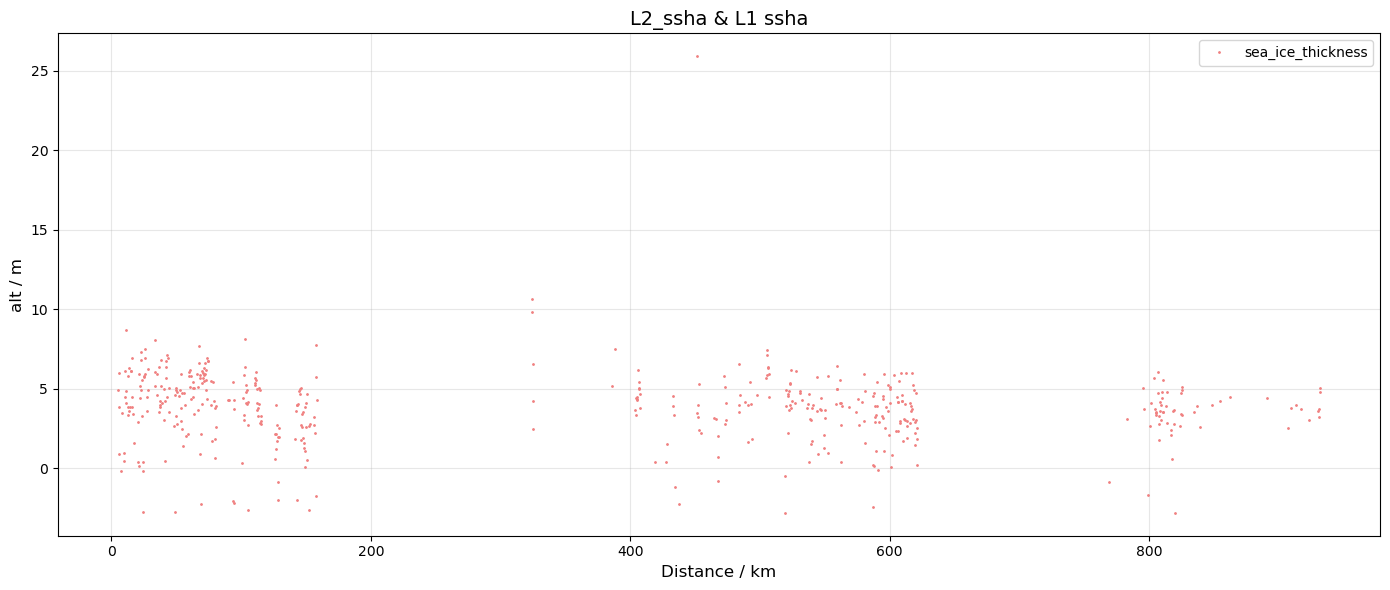

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
# plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='royalblue', markersize=2, label='ssha_L2')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['sea_ice_thickness'], '.', color='lightcoral', markersize=2, label='sea_ice_thickness')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_ssha & L1 ssha', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# version


In [155]:
import numpy as np
import scipy.ndimage
import netCDF4 as nc
import matplotlib.pyplot as plt

# 对波形进行插值（10倍过采样）
def oversample_waveform(waveform, factor=10):
    """
    采用线性插值对波形进行 10 倍过采样
    """
    rangeBins = np.arange(waveform.shape[1])  # 原始采样点
    rangeBins_new = np.linspace(0, waveform.shape[1] - 1, waveform.shape[1] * factor)  # 过采样点
    waveform_interp = np.array([np.interp(rangeBins_new, rangeBins, w) for w in waveform])  # 对每条波形插值
    return waveform_interp
# 应用平滑滤波
def smooth_waveform(waveform_interp, mode="SAR"):
    """
    使用 box 滤波器平滑波形, SAR 模式窗口大小为 11.SARIn 为 21
    """
    filter_size = 11 if mode == "SAR" else 21
    waveform_smoothed = np.array([scipy.ndimage.uniform_filter1d(w, size=filter_size) for w in waveform_interp])
    return waveform_smoothed

# 归一化波形
def normalize_waveform(waveform_smoothed):
    """
    归一化，使最大值变为 1.0
    """
    max_vals = np.max(waveform_smoothed, axis=1, keepdims=True)
    waveform_normalized = waveform_smoothed / max_vals
    return waveform_normalized


# def find_TFMRA_range(waveform_normalized, mode):
#     """
#     计算 TFMRA 反演点，确保 max_idx 选取真正的波峰
#     """
#     threshold_first_max = 0.15 if mode == "SAR" else 0.45  # 第一峰值阈值
#     retrack_threshold = 0.5  # 50% 阈值
#     bin_size = 0.2342  # 每个 bin 代表的物理距离 (m)
#     #bin_size = 0.4684
#     retracker_range = np.full(waveform_normalized.shape[0], np.nan)  # 初始化结果
#     # 动态获取当前模式下的总 bins 数（过采样后）
#     total_bins_oversampled = waveform_normalized.shape[1]
    
#     for i, waveform in enumerate(waveform_normalized):
#         # 1. 找到所有波峰（局部最大值）
#         peaks, _ = scipy.signal.find_peaks(waveform)
        
#         if len(peaks) == 0:
#             print(f"Warning: No peak found for waveform {i}")
#             continue  # 跳过无峰值的波形
        
#         # 2. 找到第一个大于 threshold_first_max 的真正波峰
#         valid_peaks = [p for p in peaks if waveform[p] > threshold_first_max]
#         if not valid_peaks:
#             print(f"Warning: No peak above threshold for waveform {i}")
#             continue  # 跳过无合适波峰的波形
        
#         max_idx = valid_peaks[0]  # 选取第一个超过阈值的波峰索引
#         print(f"Waveform {i}: Selected peak at {max_idx}, value={waveform[max_idx]:.3f}")

#         # 3. 在波峰前寻找 50% 截止点
#         # 3. 计算相对于“第一个峰值”的 50% 阈值
#         actual_threshold = waveform[max_idx] * 0.5
#         # 4. 从峰值位置向左（回溯）寻找前缘交点
#         for j in range(max_idx - 1, -1, -1):
#             # 找到跨越阈值的两个点：waveform[j] 在下，waveform[j+1] 在上
#             if waveform[j] <= actual_threshold <= waveform[j + 1]:
#                 # 线性插值计算精确位置
#                 frac = (actual_threshold - waveform[j]) / (waveform[j + 1] - waveform[j])
#                 retracker_range[i] = j + frac
#                 print(f"Waveform {i} retracker bin: {retracker_range[i]}")
#                 break
            
#         # for j in range(max_idx):
#         #     if waveform[j] <= retrack_threshold <= waveform[j + 1]:
#         #         print('YES! Found retracker point!')
#         #         frac = (retrack_threshold - waveform[j]) / (waveform[j + 1] - waveform[j])
#         #         retracker_range[i] = j + frac
#         #         print(f"Waveform {i} retracker bin: {retracker_range[i]}")
#         #         break

#     # 计算测量得到的 range_measured（不包括 window_del）
#     #range_measured = retracker_range * (bin_size / 10)  # 10x 过采样后的 bin size
#     # 如果 window_del 是窗口末端参考，则用总 bins：
#     range_correction = (retracker_range - reference_point*10) * (bin_size / 10)
#     return range_correction
def find_TFMRA_range(waveform_normalized, mode="SAR"):
    """
    计算 TFMRA 反演点，确保 max_idx 选取真正的波峰
    """
    threshold_first_max = 0.15 if mode == "SAR" else 0.5  # 第一峰值阈值
    retrack_threshold = 0.5  # 50% 阈值
    bin_size = 0.2342  # 每个 bin 代表的物理距离 (m)
    #bin_size = 0.4684
    retracker_range = np.full(waveform_normalized.shape[0], np.nan)  # 初始化结果
    
    for i, waveform in enumerate(waveform_normalized):
        # 1. 找到所有波峰（局部最大值）
        peaks, _ = scipy.signal.find_peaks(waveform)
        
        if len(peaks) == 0:
            print(f"Warning: No peak found for waveform {i}")
            continue  # 跳过无峰值的波形
        
        # 2. 找到第一个大于 threshold_first_max 的真正波峰
        valid_peaks = [p for p in peaks if waveform[p] > threshold_first_max]
        if not valid_peaks:
            print(f"Warning: No peak above threshold for waveform {i}")
            continue  # 跳过无合适波峰的波形
        
        max_idx = valid_peaks[0]  # 选取第一个超过阈值的波峰索引
        print(f"Waveform {i}: Selected peak at {max_idx}, value={waveform[max_idx]:.3f}")

        # 3. 在波峰前寻找 50% 截止点
        for j in range(max_idx):
            if waveform[j] <= retrack_threshold <= waveform[j + 1]:
                print('YES! Found retracker point!')
                frac = (retrack_threshold - waveform[j]) / (waveform[j + 1] - waveform[j])
                retracker_range[i] = j + frac
                print(f"Waveform {i} retracker bin: {retracker_range[i]}")
                break

    # 计算测量得到的 range_measured（不包括 window_del）
    #range_measured = retracker_range * (bin_size / 10)  # 10x 过采样后的 bin size
    range_correction = ( retracker_range - 1280  )* (bin_size / 10)  # 10x 过采样后的 bin size
    return range_correction

def compute_final_range(range_correction, window_del):
    """
    计算最终的 range
    """
    window_del_seconds = window_del # * 1e-12  # 由 CryoSat-2 L1B 文件中的 scale_factor 确定
    range_final = (window_del_seconds * c) / 2 + range_correction
    
    return range_final

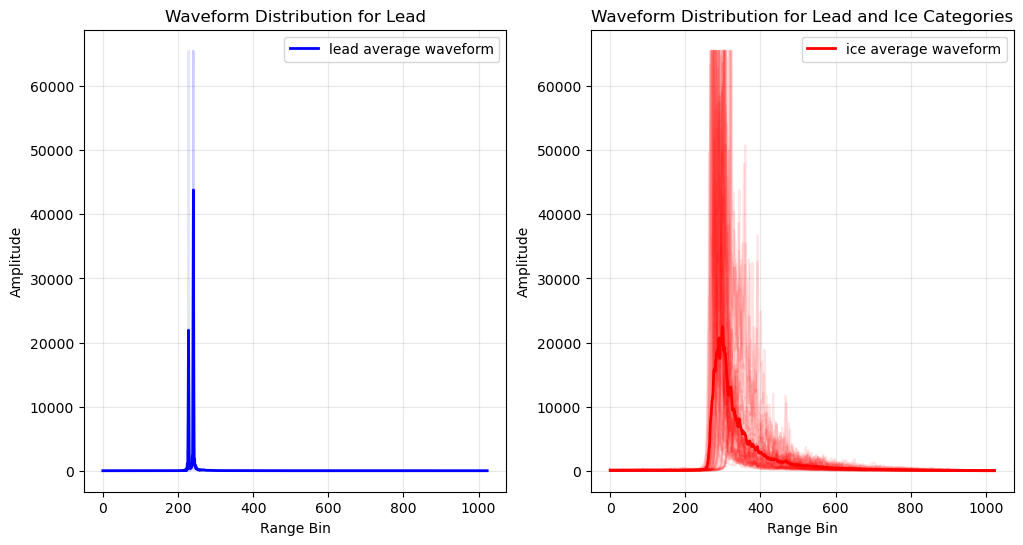

-185.16
-187.94


In [156]:
# Plot waveforms for 'lead' and 'ice' categories
plt.figure(figsize=(12, 6))

# Plot waveforms for 'lead' category
plt.subplot(1, 2, 1)
lead_mask = df['type'] == 'lead'
if lead_mask.any():
    for waveform in waveform_20_ku[lead_mask][:50]:  # Only plot the first 50 waveforms
        plt.plot(waveform, color='blue', alpha=0.1)
    plt.plot(waveform_20_ku[lead_mask][:50].mean(axis=0), label='lead average waveform', color='blue', linewidth=2)
plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Lead')
plt.legend()
plt.grid(alpha=0.3)

# Plot waveforms for 'ice' category
plt.subplot(1, 2, 2)
ice_mask = df['type'] == 'ice'
if ice_mask.any():
    for waveform in waveform_20_ku[ice_mask][:50]:  # Only plot the first 50 waveforms
        plt.plot(waveform, color='red', alpha=0.1)
    plt.plot(waveform_20_ku[ice_mask][:50].mean(axis=0), label='ice average waveform', color='red', linewidth=2)
plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Ice')
plt.legend()
plt.grid(alpha=0.3)

plt.xlabel('Range Bin')
plt.ylabel('Amplitude')
plt.title('Waveform Distribution for Lead and Ice Categories')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(noise_power_20_ku[100])
print(noise_power_20_ku[1000])

In [94]:
mode

'SARin'

Waveform 0: Selected peak at 3235, value=1.000
YES! Found retracker point!
Waveform 0 retracker bin: 3207.1025995226237
Waveform 1: Selected peak at 3217, value=1.000
YES! Found retracker point!
Waveform 1 retracker bin: 3187.7757254510166
Waveform 2: Selected peak at 3206, value=1.000
YES! Found retracker point!
Waveform 2 retracker bin: 3181.0645589047335
Waveform 3: Selected peak at 3205, value=1.000
YES! Found retracker point!
Waveform 3 retracker bin: 3163.4255674462956
Waveform 4: Selected peak at 3172, value=1.000
YES! Found retracker point!
Waveform 4 retracker bin: 3154.4422179270036
Waveform 5: Selected peak at 3160, value=1.000
YES! Found retracker point!
Waveform 5 retracker bin: 3146.201848077268
Waveform 6: Selected peak at 3152, value=1.000
YES! Found retracker point!
Waveform 6 retracker bin: 3132.851075389777
Waveform 7: Selected peak at 3123, value=1.000
YES! Found retracker point!
Waveform 7 retracker bin: 3104.1384804899103
Waveform 8: Selected peak at 3115, value=1

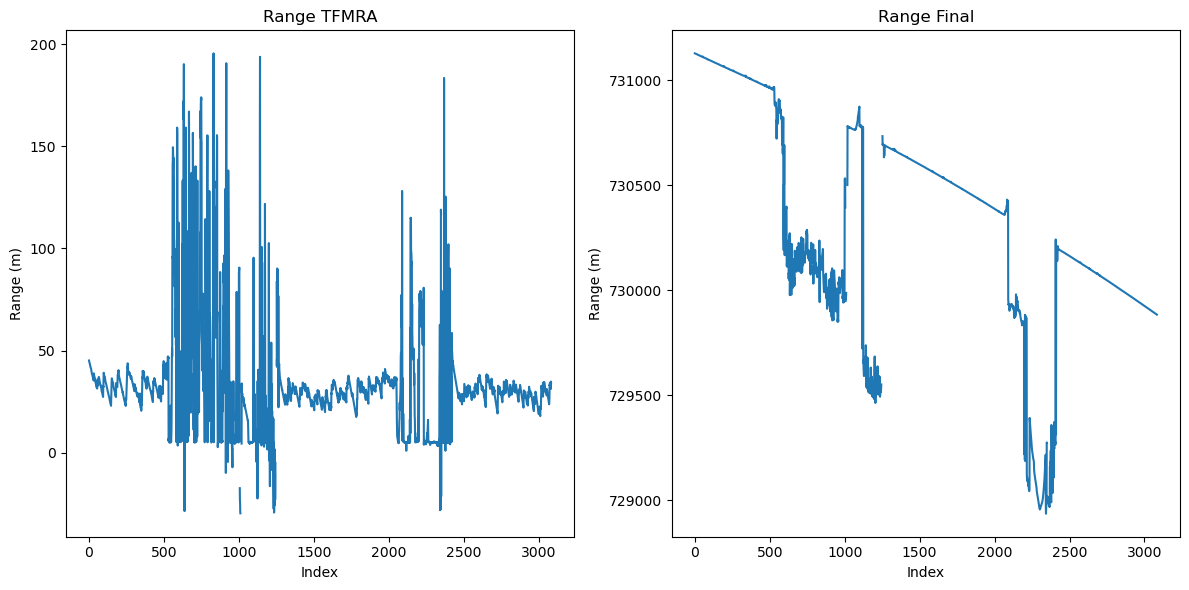

In [157]:
#waveform = np.array(df['waveform_20_ku'].tolist())
waveform = waveform_20_ku - noise_power_real[:, np.newaxis]
waveform_interp = oversample_waveform(waveform, factor=10)
waveform_smoothed = smooth_waveform(waveform_interp, mode=mode)
waveform_normalized = normalize_waveform(waveform_smoothed)
window_del = df['window_del_seconds'].values

min_lat, max_lat = df_L1['lat'].min(), df_L1['lat'].max()
min_lon, max_lon = df_L1['lon'].min(), df_L1['lon'].max()

# Apply region clipping to the waveform data
region_mask = (
    (df['lat'] >= min_lat) & (df['lat'] <= max_lat) &
    (df['lon'] >= min_lon) & (df['lon'] <= max_lon)
)

##################################################
####从df直接读取的数据Mask到指定位置
##################################################

waveform_normalized = waveform_normalized[region_mask]
window_del = window_del[region_mask]

range_TFMRA = find_TFMRA_range(waveform_normalized, mode="SARin")

range_window_del = df['window_del_seconds'][region_mask].values*c/2  # 计算 window_del 对应的 range
range_final = compute_final_range(range_TFMRA, window_del)

# Assign TFMRA-related results to the DataFrame
df_L1['range_TFMRA'] = range_TFMRA
df_L1['range_final'] = range_final
df_L1['range_window_del'] = range_window_del

plt.figure(figsize=(12, 6))

# Plot range_TFMRA
plt.subplot(1, 2, 1)
plt.plot(range_TFMRA)
plt.title('Range TFMRA')
plt.xlabel('Index')
plt.ylabel('Range (m)')

# Plot range_final
plt.subplot(1, 2, 2)
plt.plot(range_final)
plt.title('Range Final')
plt.xlabel('Index')
plt.ylabel('Range (m)')

plt.tight_layout()
plt.show()
plt.show()

In [52]:
print("df_L1['type'] value counts:")
print(df_L1['type'].value_counts(dropna=False))

df_L1['type'] value counts:
ice        2250
unknown     768
lead          6
Name: type, dtype: int64


In [109]:
from scipy.interpolate import griddata

mss_file = r"E:\CryoSat-2 L1\DTU21MSS_1min_WGS84.nc"
ds_mss = xr.open_dataset(mss_file)

# 转换经度范围 [0, 360] -> [-180, 180]
lon_mss = ds_mss['lon'].values
lat_mss = ds_mss['lat'].values
lon_mss[lon_mss > 180] -= 360

# meshgrid 成二维坐标点（MSS是规则网格）
lon_mss_grid, lat_mss_grid = np.meshgrid(lon_mss, lat_mss)
mss_data = ds_mss['mean_sea_surf_sol2'].values  # shape = (lat, lon)


# 从 df_L1 中获取经纬度边界
# updates: 2025/5/7 将df_L1先按照region筛选裁剪
min_lon, max_lon = df_L1['lon'].min(), df_L1['lon'].max()
min_lat, max_lat = df_L1['lat'].min(), df_L1['lat'].max()

print(f"自动识别裁剪范围:lon({min_lon:.2f}, {max_lon:.2f}), lat({min_lat:.2f}, {max_lat:.2f})")

# 裁剪 MSS 数据（使用更安全的 where）
mss_clipped = ds_mss.where(
    (ds_mss.lon >= min_lon) & (ds_mss.lon <= max_lon) &
    (ds_mss.lat >= min_lat) & (ds_mss.lat <= max_lat),
    drop=True
)
lon_grid, lat_grid = np.meshgrid(mss_clipped.lon.values, mss_clipped.lat.values)
print(f"MSS 裁剪后尺寸:lon={mss_clipped.sizes['lon']}, lat={mss_clipped.sizes['lat']}")

# Flatten the 2D grid for use in griddata
mss_interp = griddata(
    (lon_grid.flatten(), lat_grid.flatten()),
    mss_clipped.mean_sea_surf_sol2.values.flatten(),
    (df_L1['lon'], df_L1['lat']),
    method='linear'
)

# 8. 将插值结果添加回原数据
df_L1['mss_interp'] = (mss_interp)

print("MSS 数据处理完成，并已插值到轨迹点！")

FileNotFoundError: [Errno 2] No such file or directory: b'E:\\CryoSat-2 L1\\DTU21MSS_1min_WGS84.nc'

In [54]:
print("df_L1['type'] value counts:")
print(df_L1['type'].value_counts(dropna=False))

df_L1['type'] value counts:
ice        2250
unknown     768
lead          6
Name: type, dtype: int64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


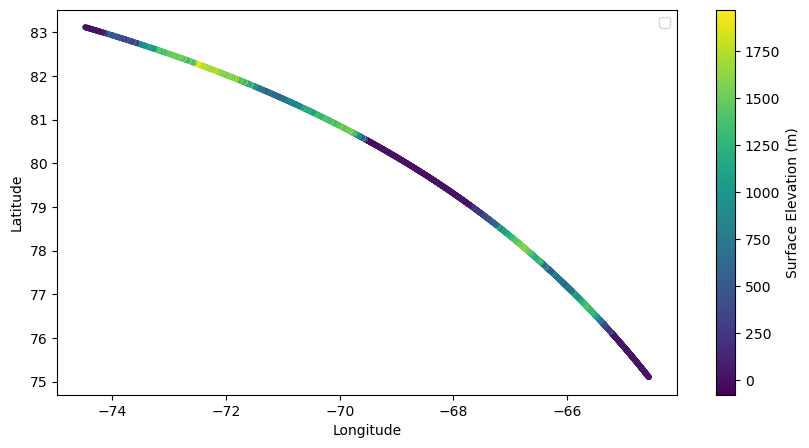

In [55]:
h_surface = df_L1['alt'] - df_L1['range_final'] - df_L1['corrections_sum']

df_L1['h_surface'] = h_surface
df_L1['corrections_sum'] = corrections_sum 
df_L1['h_surface_no_TFMRA'] = df_L1['alt'] - df_L1['range_window_del'] + df_L1['corrections_sum']
# 5. 可视化地表高程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_L1["lon"], df_L1["lat"], c=h_surface, cmap="viridis", s=10)
plt.colorbar(sc, label="Surface Elevation (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()
plt.show()

### for plotting distance calculation

In [56]:
from geopy.distance import geodesic
distance_km = [0]

for i in range(1, len(df_L1)):
    coord1 = (df_L1['lat'].iloc[i-1], df_L1['lon'].iloc[i-1])
    coord2 = (df_L1['lat'].iloc[i], df_L1['lon'].iloc[i])
    d = geodesic(coord1, coord2).km
    distance_km.append(distance_km[-1] + d)

df_L1['distance'] = distance_km

In [57]:
print("df_L1['type'] value counts:")
print(df_L1['type'].value_counts(dropna=False))

df_L1['type'] value counts:
ice        2250
unknown     768
lead          6
Name: type, dtype: int64


## export df result first

In [ ]:
# import os

# # Define the output directory
# output_dir = r"E:\CryoSat-2 L1\20220815-0930 Dyice region\L1 df output"

# # Ensure the directory exists
# os.makedirs(output_dir, exist_ok=True)

# # Define the output file path
# input_file_name = os.path.basename(L1_path).replace(".nc", "")
# output_file = os.path.join(output_dir, f"df_L1_{input_file_name}.parquet")

# # Save the DataFrame
# df_L1.to_parquet(output_file, index=False)

# print(f"File saved to: {output_file}")

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

## calculate sea surface height anomaly

plt.plot() 默认是连线的
它会默认将数值连续地连接成线段。

掩膜 .loc[lead_mask, 'SLA_raw'] 是连续索引
lead_mask 会筛选出 'type' == 'lead' 的行，然后扔掉其他的行，也就是 丢掉了 NaN 和非-lead 的值，所以这时候传给 plot 的是一个没有 NaN 的连续向量。

👉 所以：它就直接画成了连续的线！

相反，df_L1['SLA_raw'] 包含了 NaN
所以这时候 plt.plot() 会自动“断开”线段，也就是哪里是 NaN，哪里就不画。

In [58]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import pandas as pd

# === Step 0: 初始化 ===
# 确保 type 字段中标记了 lead 点
lead_mask = (df_L1['type'] == 'lead')

# 计算 SLA_raw（只在 lead 点计算）
df_L1['SLA_raw'] = np.nan
df_L1.loc[lead_mask, 'SLA_raw'] = df_L1.loc[lead_mask, 'h_surface'] - df_L1.loc[lead_mask, 'mss_interp']

# 提取有效的 lead 点索引和 SLA_raw 数值
lead_indices = df_L1.index[lead_mask].to_numpy()
SLA_raw_values = df_L1.loc[lead_mask, 'SLA_raw'].to_numpy()
print(np.sum(~np.isnan(SLA_raw_values)))

KeyError: 'mss_interp'

In [ ]:
# === Step 1: 对 SLA_raw 做 100 km 滤波（滑动窗口大小假设为 5）===
# 滤波仅在有效值上进行，避免 NaN 扩散
# 转为 Series 以用 rolling
# 计算 100km 对应的 bin 数量（假设 sampling 约为 380m）
filter_size_bins = int(100000 / 380) 
limit_dist_bins = filter_size_bins * 2  # 200km

SLA_raw_series = pd.Series(SLA_raw_values, index=lead_indices)

# # 使用窗口大小为5，跳过 NaN 的平均（min_periods=1 表示至少1个非NaN就计算）
# SLA_smoothed_raw = SLA_raw_series.rolling(window=5, center=True, min_periods=1).mean()
# Step 1: 对 SLA_raw 做 100 km 滤波（仅针对 lead 点）
SLA_smoothed_raw = SLA_raw_series.rolling(window=filter_size_bins, center=True, min_periods=1).mean()

print(np.sum(~np.isnan(SLA_smoothed_raw)))



381


In [ ]:
# # === Step 3: 插值到全轨迹（包括非-lead点） ===
# interp_func = interp1d(
#     SLA_smoothed_raw.index,
#     SLA_smoothed_raw.values,
#     kind='linear',
#     bounds_error=False,
#     fill_value="extrapolate"
# )
# df_L1['SLA_interp'] = interp_func(df_L1.index)

# Step 2: 线性插值到全轨迹
interp_func = interp1d(SLA_smoothed_raw.index, SLA_smoothed_raw.values, kind='linear', bounds_error=False)
df_L1['SLA_interp'] = interp_func(df_L1.index)

In [83]:
print(df_L1['SLA_interp'].isna().sum())
print(df_L1['SLA_interp'].describe)

0
<bound method NDFrame.describe of 0       0.701636
1       0.701238
2       0.700840
3       0.700443
4       0.700045
          ...   
8729    0.124231
8730    0.119295
8731    0.114360
8732    0.109425
8733    0.104489
Name: SLA_interp, Length: 8734, dtype: float64>


In [ ]:
# # === Step 4: 对插值结果再次平滑 ===
# # 注意 uniform_filter1d 无法处理 NaN，因此先填补（再可选恢复）
# interp_array = df_L1['SLA_interp'].interpolate(method='nearest').to_numpy()
# SLA_final = uniform_filter1d(interp_array, size=5, mode='nearest')
# df_L1['SLA'] = SLA_final


# Step 3: 对插值结果做第二次 100 km 滤波
# 注意：需要处理插值产生的 NaN，或者在滤波后重新 apply mask
df_L1['SLA_final'] = uniform_filter1d(df_L1['SLA_interp'].ffill().bfill(), size=filter_size_bins)
# 保存最终结果
df_L1['SLA'] = df_L1['SLA_final'] 


In [ ]:
print(df_L1['SLA'].describe())  

count    8734.000000
mean        0.256111
std         0.105517
min         0.107451
25%         0.197334
50%         0.224491
75%         0.278601
max         0.701397
Name: SLA, dtype: float64


In [ ]:
# Step 4: 距离检查，超过 200km 设为 NaN
# 计算每个 index 到最近 lead index 的距离（需根据实际采样率换算为 km）
# 示例：若 index 是连续的，则直接用索引差值判断
# if abs(current_index - nearest_lead_index) > limit_dist_bins: SLA = NaN

检查中间计算过程

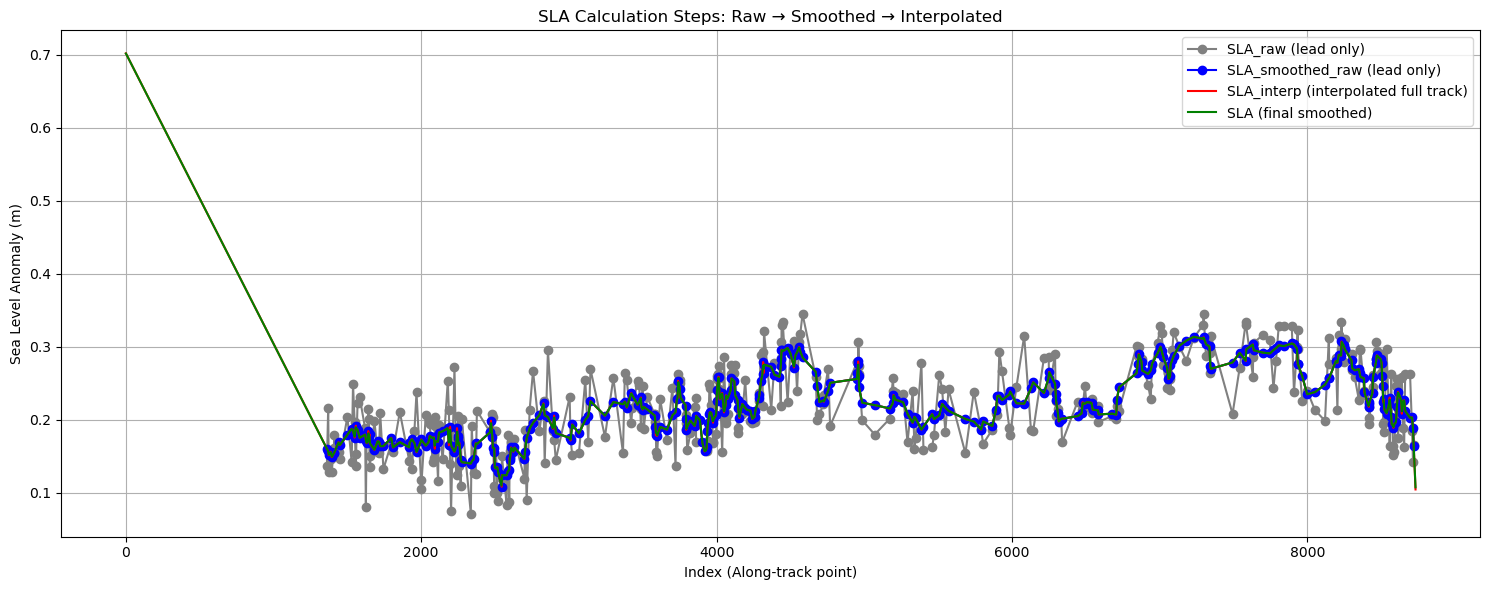

In [86]:
import matplotlib.pyplot as plt

# 假设你已经有这些变量：
# - df_L1（包含最终插值得到的 df_L1['SLA']）
# - SLA_raw_series（原始的 SLA_raw，pandas Series，索引是 lead_indices）
# - SLA_smoothed_raw（在 lead 上平滑后的值，Series，同样索引是 lead_indices）

plt.figure(figsize=(15, 6))

# Step 1: 原始 SLA_raw
plt.plot(SLA_raw_series.index, SLA_raw_series.values, 'o-', label='SLA_raw (lead only)', color='gray')

# Step 2: 平滑后 SLA
plt.plot(SLA_smoothed_raw.index, SLA_smoothed_raw.values, 'o-', label='SLA_smoothed_raw (lead only)', color='blue')

# Step 3: 插值得到的连续 SLA（整条轨迹）
plt.plot(df_L1.index, df_L1['SLA_interp'], '-', label='SLA_interp (interpolated full track)', color='red')

# Step 4: 最终平滑后的 SLA
plt.plot(df_L1.index, df_L1['SLA'], '-', label='SLA (final smoothed)', color='green')

plt.xlabel('Index (Along-track point)')
plt.ylabel('Sea Level Anomaly (m)')
plt.title('SLA Calculation Steps: Raw → Smoothed → Interpolated')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [87]:
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import numpy as np
from haversine import haversine, Unit
from sklearn.neighbors import BallTree



# Step 4: 找每一点到最近 lead 的实际距离
from scipy.spatial import cKDTree
import numpy as np

# 地球半径（单位：km）
#R = 6371.0
R = 6371000.0  



# 提取经纬度数组
all_coords = df_L1[['lat', 'lon']].to_numpy()
lead_coords = df_L1.loc[lead_mask, ['lat', 'lon']].to_numpy()

# 是否是 lead 点
is_lead = lead_mask.to_numpy()
distances = np.zeros(len(all_coords))

for i, (lat1, lon1) in enumerate(all_coords):
    d_list = [haversine((lat1, lon1), (lat2, lon2), unit=Unit.METERS) for lat2, lon2 in lead_coords]

    if is_lead[i] and len(d_list) > 1:
        # 是 lead 点，取第 2 小值
        d_sorted = sorted(d_list)
        distances[i] = d_sorted[1]
    else:
        # 非 lead 点，取最小值
        distances[i] = min(d_list)

df_L1['dist_to_lead'] = distances


print(df_L1['dist_to_lead'].describe())



count      8734.000000
mean      35281.168856
std       87374.688851
min         303.218972
25%        1213.881191
50%        3034.961159
75%        7892.807852
max      412597.904958
Name: dist_to_lead, dtype: float64


In [192]:
# 7. 对于 dist_to_lead > 200km 的点，设置 SLA 为 NaN
df_L1.loc[df_L1['dist_to_lead'] > 200000, 'SLA'] = np.nan

print(df_L1['SLA'].describe())

# 8. 计算 radar freeboard：只在 sea ice 点
ice_mask = df_L1['type'] == 'ice'
df_L1['radar_freeboard'] = np.nan
df_L1.loc[ice_mask, 'radar_freeboard'] = df_L1.loc[ice_mask, 'h_surface'] - (
    df_L1.loc[ice_mask, 'mss_interp'] + df_L1.loc[ice_mask, 'SLA']
)

print(df_L1['radar_freeboard'].describe())
# 4.3.7 筛选雷达自由板
# 设置不符合范围的值为 NaN
valid_freeboard_mask = (df_L1['radar_freeboard'] >= -0.25) & (df_L1['radar_freeboard'] <= 2.25)
df_L1['radar_freeboard'] = df_L1['radar_freeboard'].where(valid_freeboard_mask, np.nan)

# 打印筛选后的 radar freeboard 描述信息
print(df_L1['radar_freeboard'].describe())


count    8032.000000
mean        0.229352
std         0.051282
min         0.107451
25%         0.193993
50%         0.221693
75%         0.265761
max         0.422519
Name: SLA, dtype: float64
count    2482.000000
mean        0.109395
std         1.314530
min        -0.526792
25%        -0.039551
50%         0.009774
75%         0.054553
max        17.124094
Name: radar_freeboard, dtype: float64
count    2459.000000
mean        0.008129
std         0.072106
min        -0.247091
25%        -0.039054
50%         0.009454
75%         0.053865
max         0.283108
Name: radar_freeboard, dtype: float64


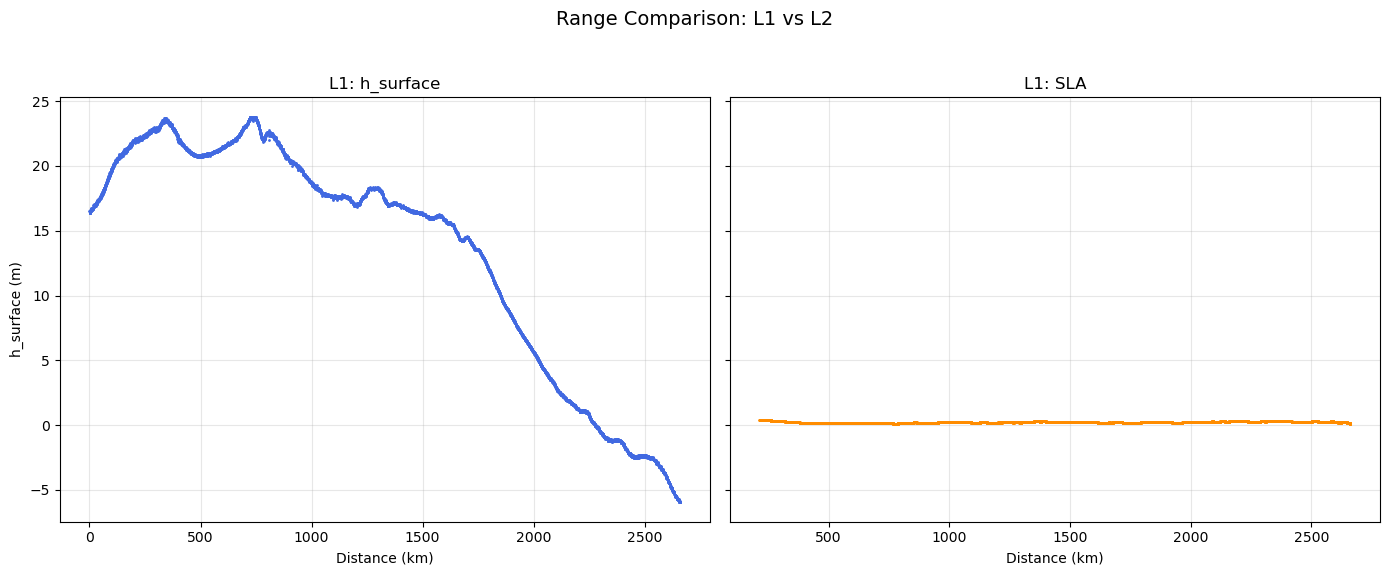

In [89]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['h_surface'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: h_surface')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L1['distance'], df_L1['SLA'], '.', color='darkorange', markersize=2)
axs[1].set_title('L1: SLA')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# L2 read

In [64]:

ds_L2 = xr.open_dataset(L2_path)

# Read time and waveform data (automatically mapped)
time_20_ku = ds_L2['time_20_ku'].values
height_1_20_ku = ds_L2['height_1_20_ku'].values
mss_seaIce = ds_L2['mean_sea_surf_sea_ice_01'].values
radar_freeboard = ds_L2['radar_freeboard_20_ku'].values
ssha = ds_L2['ssha_interp_20_ku'].values
lon = ds_L2['lon_poca_20_ku'].values
lat = ds_L2['lat_poca_20_ku'].values
lat_01 = ds_L2['lat_01'].values
lon_01 = ds_L2['lon_01'].values
range_1 = ds_L2['range_1_20_ku'].values
snow_density = ds_L2['snow_density_01'].values
snow_depth = ds_L2['snow_depth_01'].values
alt = ds_L2['alt_01'].values
height_sea_ice_floe = ds_L2['height_sea_ice_floe_20_ku'].values
height_sea_ice_lead = ds_L2['height_sea_ice_lead_20_ku'].values
surf_type = ds_L2['surf_type_20_ku'].values
tai_epoch = datetime(2000, 1, 1, 0, 0, 0)

def tai_to_utc(tai_seconds): # 将 TAI 秒数转换为 UTC 时间 
    utc_time = tai_epoch + timedelta(seconds=tai_seconds) 
    return utc_time

# Convert datetime64[ns] to seconds since epoch
tai_seconds = (time_20_ku - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
utc_time = np.array([tai_to_utc(t) for t in tai_seconds])



## 没有indice,找最近点插值

In [65]:
# 假设你想创建一个 DataFrame 来存储所有这些变量
df_L2 = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'height_1_20_ku': height_1_20_ku,  
    'radar_freeboard': radar_freeboard,
    'ssha': ssha,
    'lat': lat,
    'lon': lon,
    'height_sea_ice_floe': height_sea_ice_floe,
    'height_sea_ice_lead': height_sea_ice_lead,
    'surf_type': surf_type,
})

In [66]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree



def match_nearest_valid_value(var_data, var_lat, var_lon, target_lat, target_lon, fill_value):
    """
    用于匹配最近的有效值 去除NaN或_FillValue),支持任意变量。

    参数：
    - var_data: 待匹配的变量数据（例如 mean_sea_surf_sea_ice_01)
    - var_lat: 变量数据对应的纬度lat_01
    - var_lon: 变量数据对应的经度lon_01
    - target_lat: 目标点的纬度height的点
    - target_lon: 目标点的经度height的点
    - fill_value: 该变量的 _FillValue,NaN也可以

    返回：
    - matched_values: 每个目标点匹配到的最近有效变量值
    """
    valid_mask = (var_data != fill_value)
    tree = cKDTree(np.c_[var_lat[valid_mask], var_lon[valid_mask]])
    distances, indices = tree.query(np.c_[target_lat, target_lon], k=1)
    matched_values = var_data[valid_mask][indices]
    return matched_values

# 读取 fill_value
fill_value_sss = ds_L2["mean_sea_surf_sea_ice_01"].attrs.get("_FillValue", np.nan)
fill_value_sd = ds_L2["snow_density_01"].attrs.get("_FillValue", np.nan)
fill_value_sdp = ds_L2["snow_depth_01"].attrs.get("_FillValue", np.nan)

# 匹配最近的值
matched_mean_sss = match_nearest_valid_value(mss_seaIce, lat_01, lon_01, lat, lon, fill_value_sss)
matched_snow_density = match_nearest_valid_value(snow_density, lat_01, lon_01, lat, lon, fill_value_sd)
matched_snow_depth = match_nearest_valid_value(snow_depth, lat_01, lon_01, lat, lon, fill_value_sdp)
matched_alt = match_nearest_valid_value(alt, lat_01, lon_01, lat, lon, fill_value_sd)

In [67]:
# 假设你想创建一个 DataFrame 来存储所有这些变量
df_L2 = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'height_1_20_ku': height_1_20_ku,
    'mss_seaIce': matched_mean_sss,   
    'radar_freeboard': radar_freeboard,
    'ssha': ssha,
    'lat': lat,
    'lon': lon,
    'range_1': range_1,
    'snow_density': matched_snow_density,   
    'snow_depth': matched_snow_depth,
    'alt': matched_alt,
    'height_sea_ice_floe': height_sea_ice_floe,
    'height_sea_ice_lead': height_sea_ice_lead,
    'surf_type': surf_type,
})


## read L2 correction

In [68]:
#iono_cor_gim_01 = ds['iono_cor_gim_01'].values #* 0.001
iono_cor_01 = ds_L2['iono_cor_01'].values #* 0.001
mod_dry_tropo_cor_01 = ds_L2['mod_dry_tropo_cor_01'].values # * 0.001  # 应用缩放因子
mod_wet_tropo_cor_01= ds_L2['mod_wet_tropo_cor_01'].values #* 0.001
inv_bar_cor_01 = ds_L2['inv_bar_cor_01'].values #* 0.001
#hf_fluct_total_cor_01 = ds['hf_fluct_total_cor_01'].values #* 0.001

ocean_tide_01 = ds_L2['ocean_tide_01'].values # elastic ocean tide
ocean_tide_eq_01 = ds_L2['ocean_tide_eq_01'].values #long period ocean tide
load_tide_01 = ds_L2['load_tide_01'].values #ocean loading tide
solid_earth_tide_01 = ds_L2['solid_earth_tide_01'].values #* 0.001
pole_tide_01 = ds_L2['pole_tide_01'].values #geocentric polar tide

# 你要广播的 correction 变量
correction_vars = [
    'mod_dry_tropo_cor_01', 'mod_wet_tropo_cor_01', 'inv_bar_cor_01', 
    'iono_cor_01', 
    'ocean_tide_01', 'ocean_tide_eq_01', 'load_tide_01', 
    'solid_earth_tide_01', 'pole_tide_01'
]

# 存储所有广播后的结果
matched_corrections = {}

for var in correction_vars:
    data = ds_L2[var].values
    fill_value = ds_L2[var].attrs.get('_FillValue', np.nan)
    
    matched = match_nearest_valid_value(
        var_data=data,
        var_lat=lat_01,
        var_lon=lon_01,
        target_lat=lat,
        target_lon=lon,
        fill_value=fill_value
    )
    matched_corrections[var] = matched
# 添加到 df_L2
for var in correction_vars:
    df_L2[var] = matched_corrections[var]

# 校正总和
df_L2['corrections_sum'] = df_L2[correction_vars].sum(axis=1)



In [69]:
print(time_20_ku.shape)
print(inv_bar_cor_01.shape)
print(df_L2['corrections_sum'].shape)

(3084,)
(155,)
(3084,)


In [112]:
import pandas as pd
import numpy as np

# 假设你的 df_L2 已经用字典方式创建好了，且总长度和 L1 是一模一样的
# df_L2 = pd.DataFrame({...})

# ==========================================
# === 无损筛选：surf_type + region_mask ===
# ==========================================

# 1. 定义海洋掩膜：保留 0 (ocean) 和 1 (lake_enclosed_sea)
valid_surf_mask_L2 = (df_L2['surf_type'] == 0) | (df_L2['surf_type'] == 1)

# 2. 定义经纬度掩膜：对齐 L1 的研究区域
min_lat, max_lat = df_L1['lat'].min(), df_L1['lat'].max()
min_lon, max_lon = df_L1['lon'].min(), df_L1['lon'].max()
region_mask_L2 = (df_L2['lat'] >= min_lat) & (df_L2['lat'] <= max_lat) & \
                 (df_L2['lon'] >= min_lon) & (df_L2['lon'] <= max_lon)

# 3. 合并最终有效掩膜：必须【同时满足】是海洋且在区域内
final_valid_mask_L2 = valid_surf_mask_L2 & region_mask_L2

# 4. 指定需要清理为 NaN 的物理数据列（不要把 lat/lon 和 time 也清掉了）
cols_to_mask = [
    'height_1_20_ku', 'mss_seaIce', 'radar_freeboard', 'ssha', 
    'range_1', 'snow_density', 'snow_depth', 'alt', 
    'height_sea_ice_floe', 'height_sea_ice_lead'
]

# 5. 【最关键的一步】将所有 不符合条件 (~final_valid_mask_L2) 的行，指定列赋为 NaN
# 绝对不删除任何一行！
df_L2.loc[~final_valid_mask_L2, cols_to_mask] = np.nan

# 6. 打印检查核对
print(f"L2 原始点数 (应该和 L1 长度完美一致): {len(df_L2)}")
print(f"L2 有效数据点数 (未被设为NaN的数量): {final_valid_mask_L2.sum()}")
print(f"安全屏蔽了 {(~final_valid_mask_L2).sum()} 个非海洋或区域外干扰点。")

# 接下来就可以直接对比了！
diff_freeboard = df_L1['radar_freeboard'] - df_L2['radar_freeboard']
print("\nL1 与 L2 雷达干舷差值统计：")
print(diff_freeboard.describe())

L2 原始点数 (应该和 L1 长度完美一致): 2040
L2 有效数据点数 (未被设为NaN的数量): 2040
安全屏蔽了 0 个非海洋或区域外干扰点。

L1 与 L2 雷达干舷差值统计：
count    348.000000
mean       0.290584
std        0.542130
min       -6.934931
25%        0.288756
50%        0.344545
75%        0.379526
max        0.488687
Name: radar_freeboard, dtype: float64


In [113]:
from geopy.distance import geodesic

distance_km = [0]

for i in range(1, len(df_L2)):
    coord1 = (df_L2['lat'].iloc[i-1], df_L2['lon'].iloc[i-1])
    coord2 = (df_L2['lat'].iloc[i], df_L2['lon'].iloc[i])
    d = geodesic(coord1, coord2).km
    distance_km.append(distance_km[-1] + d)

df_L2['distance'] = distance_km

重新设定region确保Mss插值有结果

### 原来是不在范围内才会是空值，需要重新设置lat_max. lon_max等边界

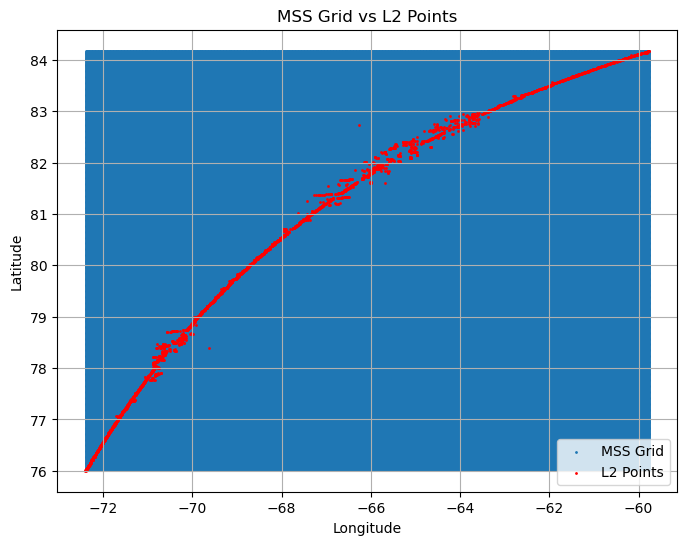

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(lon_grid.flatten(), lat_grid.flatten(), s=1, label='MSS Grid')
plt.scatter(df_L2['lon'], df_L2['lat'], color='red', s=1, label='L2 Points')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MSS Grid vs L2 Points')
plt.grid(True) 
plt.show()


# plot for comparision

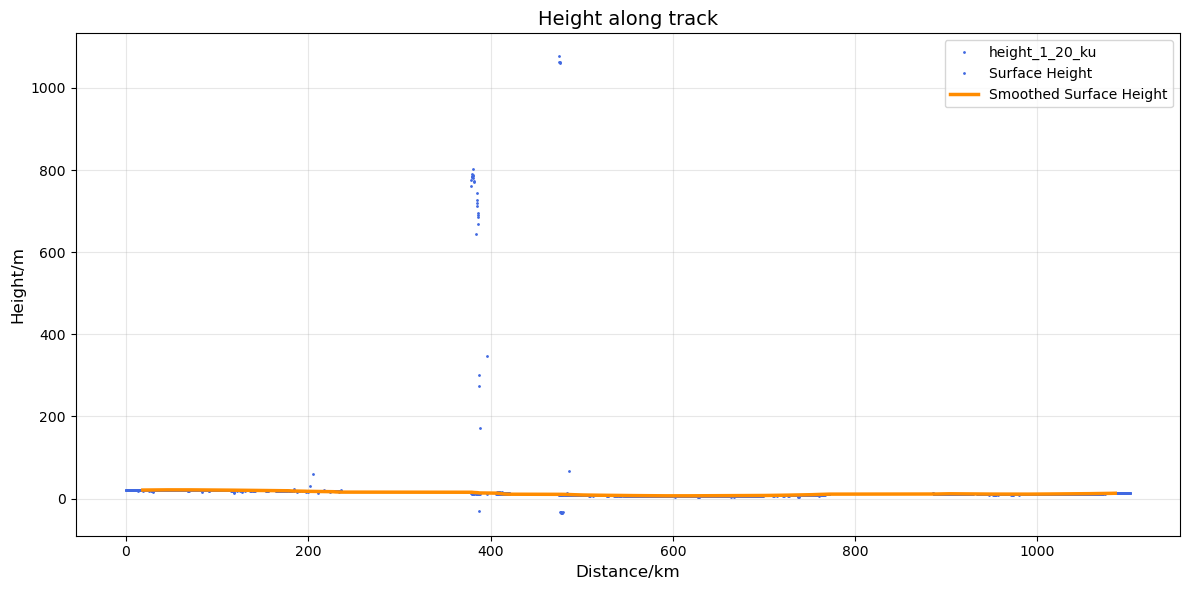

In [114]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='height_1_20_ku')
plt.plot(df_L2['distance'], df_L2['mss_seaIce'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
smooth = df_L2['mss_seaIce'].rolling(window, center=True).mean()
plt.plot(df_L2['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('Height/m', fontsize=12)
plt.title('Height along track', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


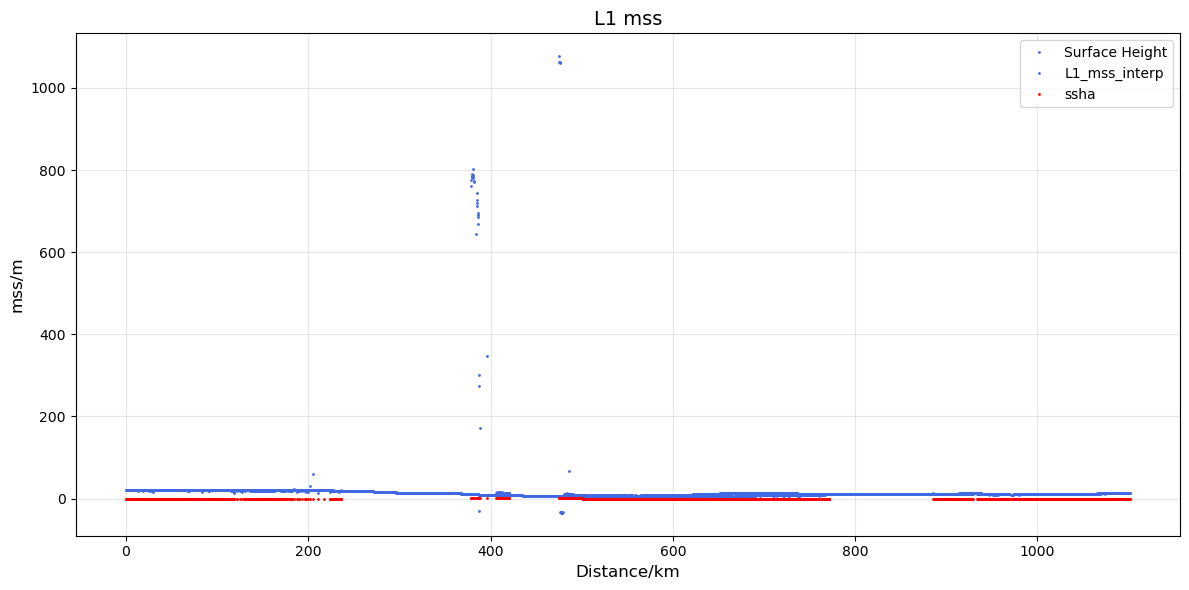

In [102]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L1['distance'], df_L1['mss_interp'], '.', color='royalblue', markersize=2, label='L1_mss_interp')
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='red', markersize=2, label='ssha')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('mss/m', fontsize=12)
plt.title('L1 mss', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### check the coverage of L1&L2

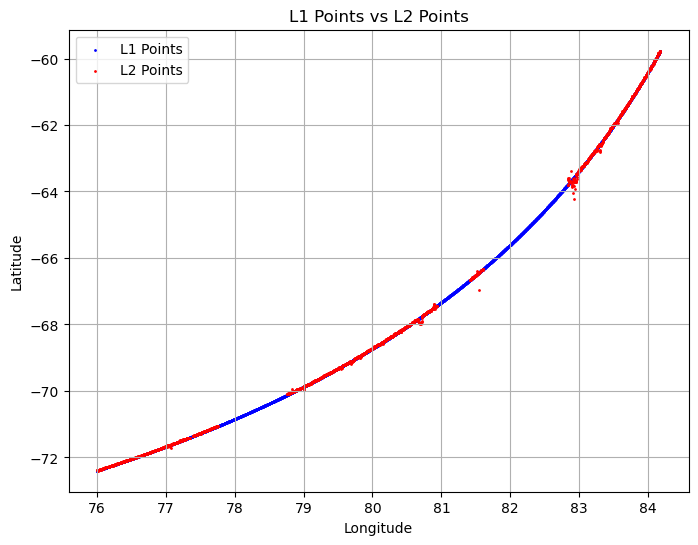

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_L1['lat'], df_L1['lon'], color='blue', s=1, label='L1 Points')
plt.scatter(df_L2['lat'], df_L2['lon'], color='red', s=1, label='L2 Points')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('L1 Points vs L2 Points')
plt.grid(True)
plt.show()

In [83]:
print(len(df_L1), len(df_L2))


3084 3084


## plot L1 TFRMA range & L2_range_01

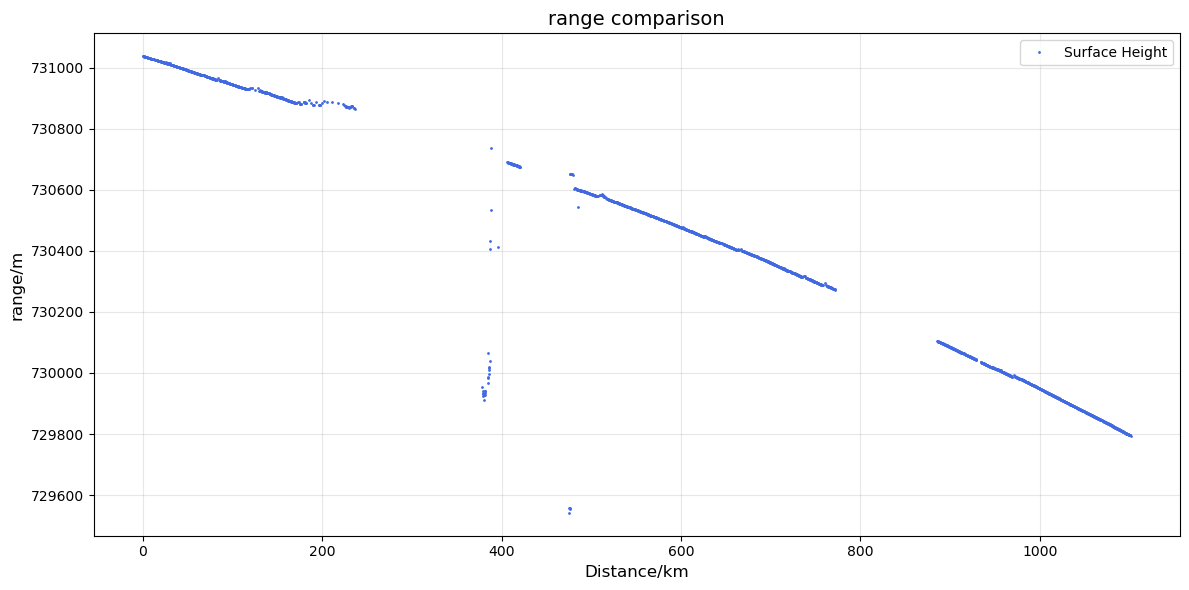

In [104]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L2['distance'], df_L2['range_1'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
# smooth = df_L2['range_1'].rolling(window, center=True).mean()
# plt.plot(df_L2['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('range/m', fontsize=12)
plt.title('range comparison', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

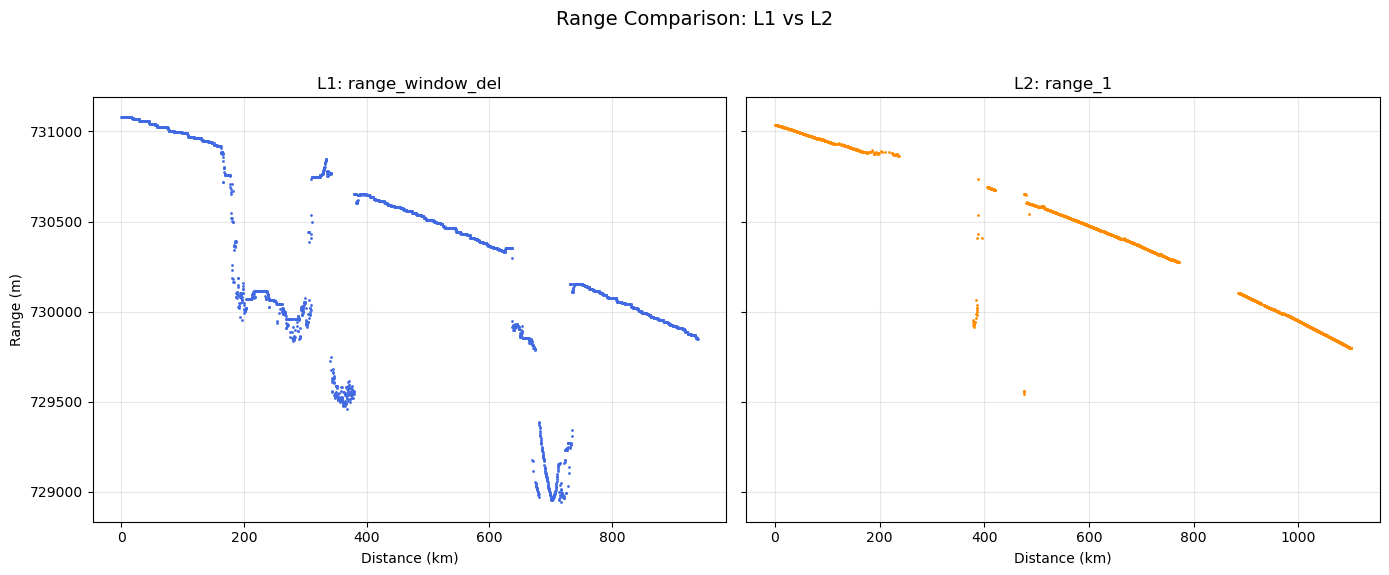

In [116]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['range_window_del'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: range_window_del')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('Range (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['range_1'], '.', color='darkorange', markersize=2)
axs[1].set_title('L2: range_1')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## plot L1 surface height & L2_height_01

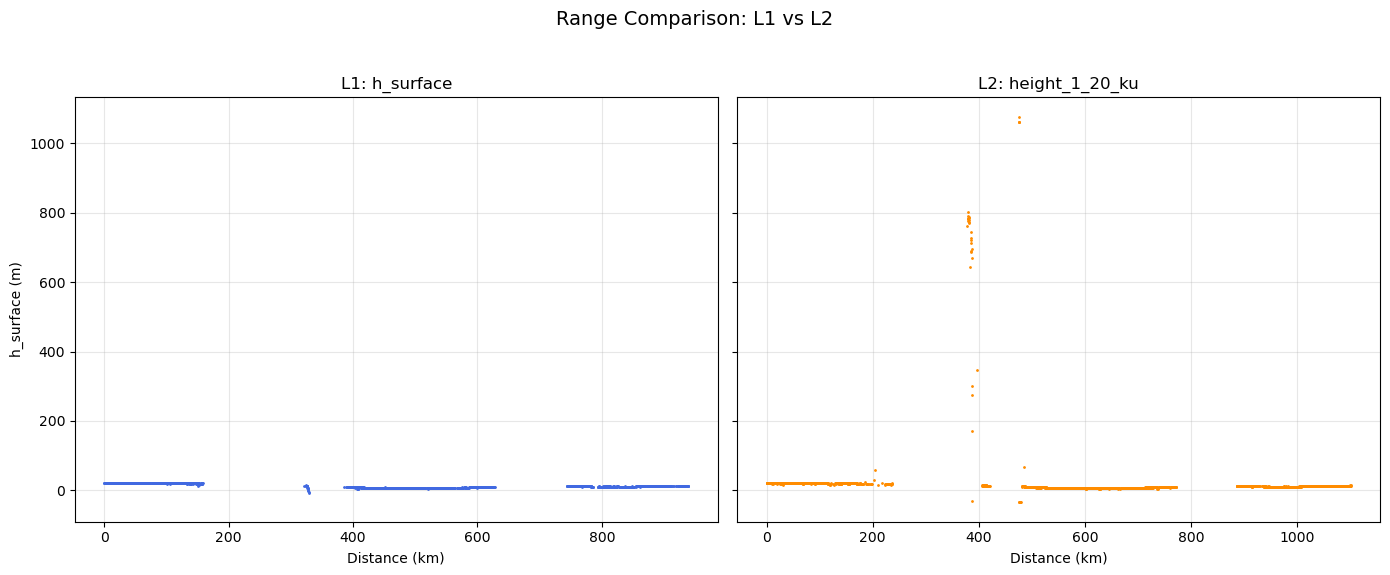

In [106]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['h_surface'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: h_surface')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='darkorange', markersize=2)
axs[1].set_title('L2: height_1_20_ku')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

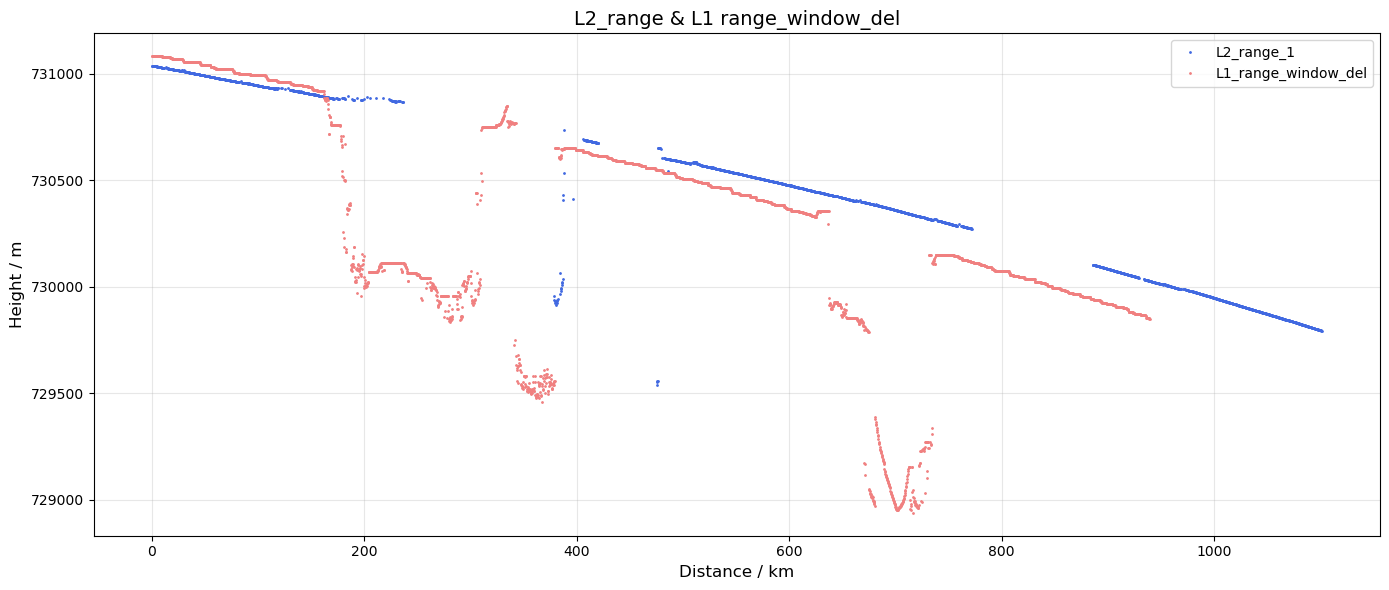

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['range_1'], '.', color='royalblue', markersize=2, label='L2_range_1')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['range_window_del'], '.', color='lightcoral', markersize=2, label='L1_range_window_del')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L2_range & L1 range_window_del', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print(df_L2)

## plot L1 ssha & L2_ssha

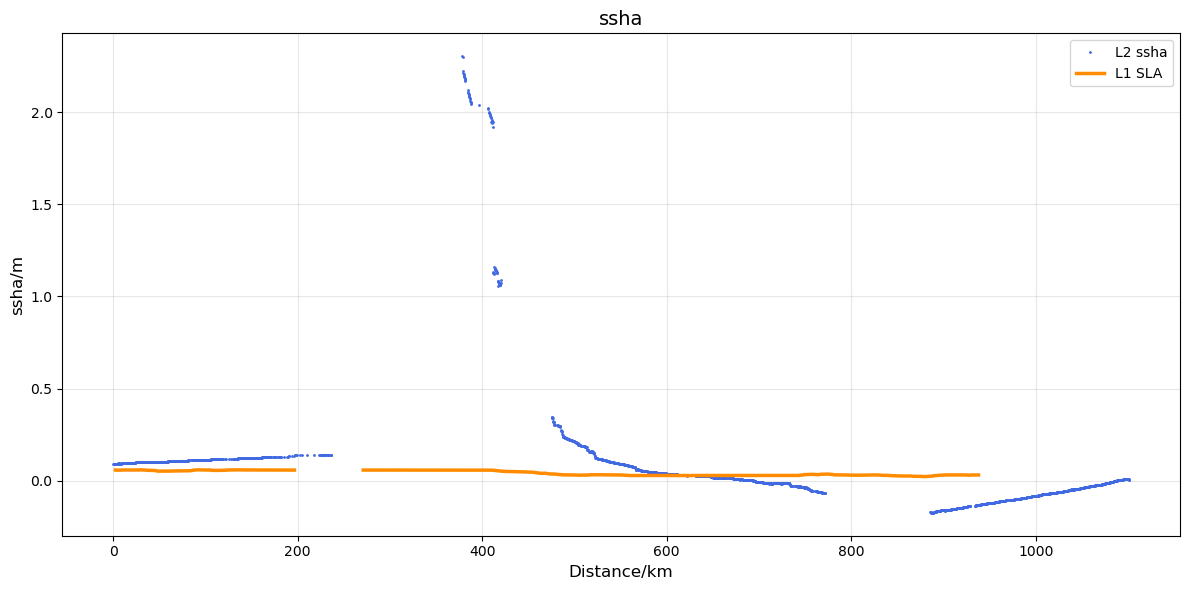

In [108]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='royalblue', markersize=2, label='L2 ssha')


plt.plot(df_L1['distance'], df_L1['SLA'], color='darkorange', linewidth=2.5, label='L1 SLA')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('ssha/m', fontsize=12)
plt.title('ssha', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## plot h surface and mean sea surface

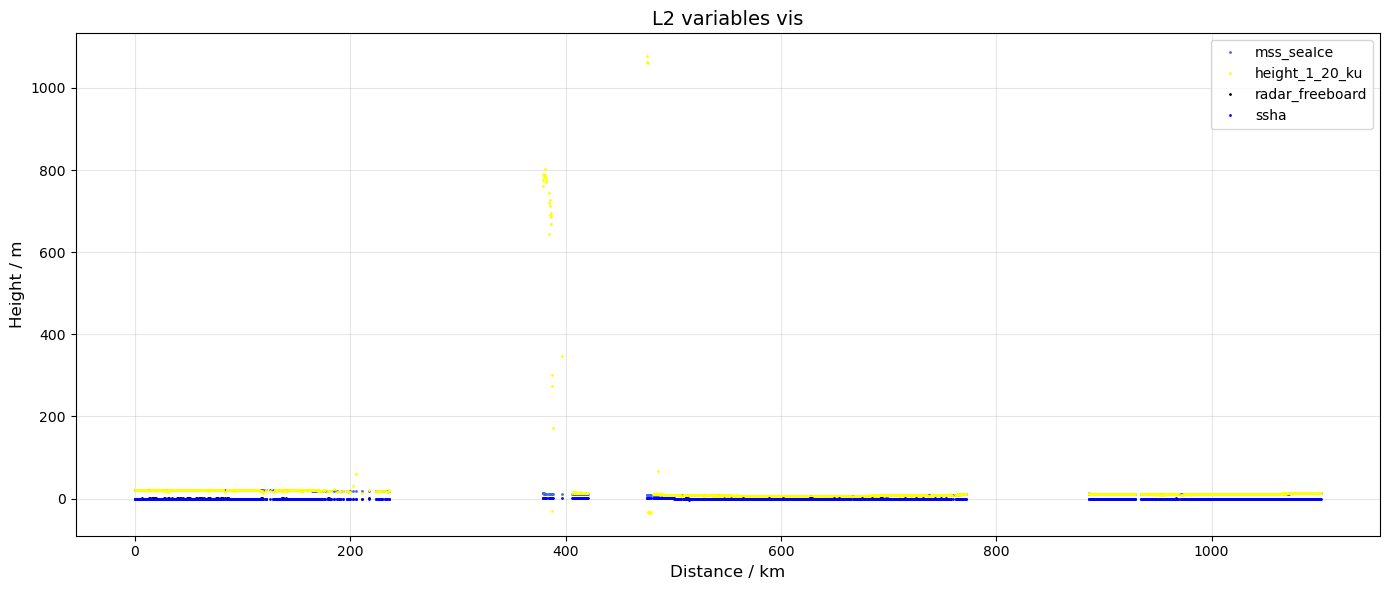

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['mss_seaIce'], '.', color='royalblue', markersize=2, label='mss_seaIce')

# # 原始点：mss_interp
plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='yellow', markersize=2, label='height_1_20_ku')

plt.plot(df_L2['distance'], df_L2['radar_freeboard'], '.', color='black', markersize=2, label='radar_freeboard')
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='blue', markersize=2, label='ssha')

# 平滑曲线：mss_seaIce
#smooth_seaIce = df_L2['mss_seaIce'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_seaIce, color='darkblue', linewidth=2.5, label='Smoothed mss_seaIce')

# 平滑曲线：mss_interp
#smooth_interp = df_L2['mss_interp'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_interp, color='darkred', linewidth=2.5, label='Smoothed mss_interp')

# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L2 variables vis', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

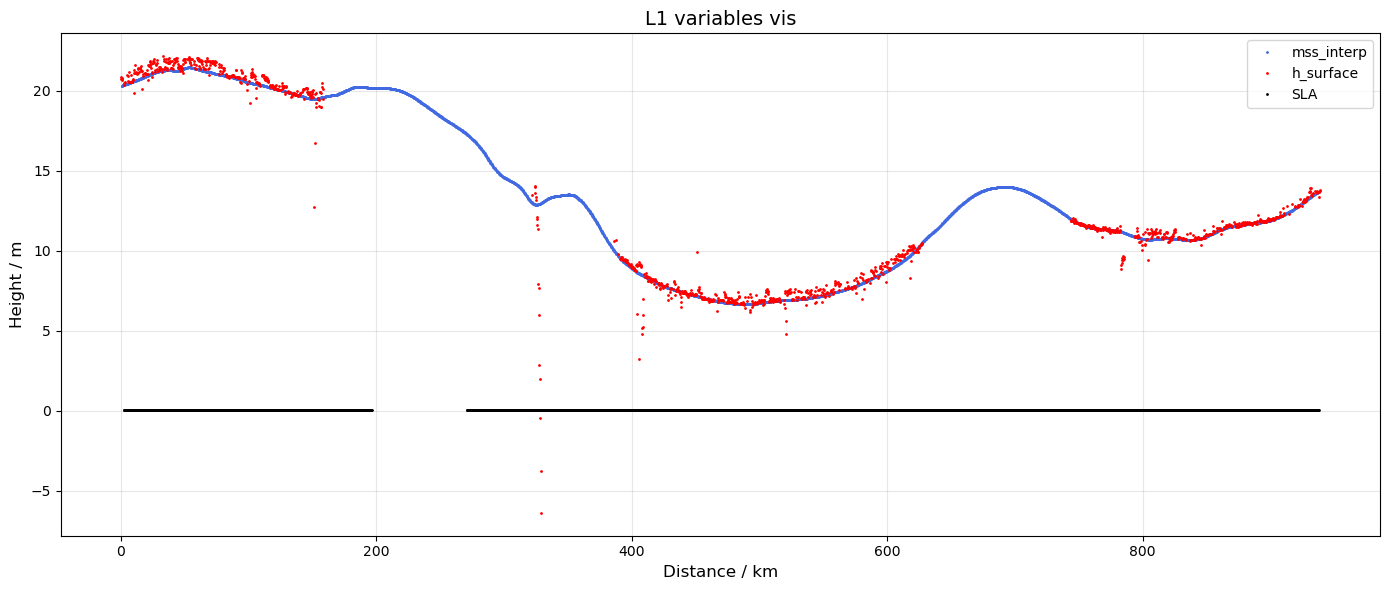

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L1['distance'], df_L1['mss_interp'], '.', color='royalblue', markersize=2, label='mss_interp')

# # 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['h_surface'], '.', color='red', markersize=2, label='h_surface')

plt.plot(df_L1['distance'], df_L1['SLA'], '.', color='black', markersize=2, label='SLA')
# plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='blue', markersize=2, label='ssha')



# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L1 variables vis', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (2040,) and (3084,)

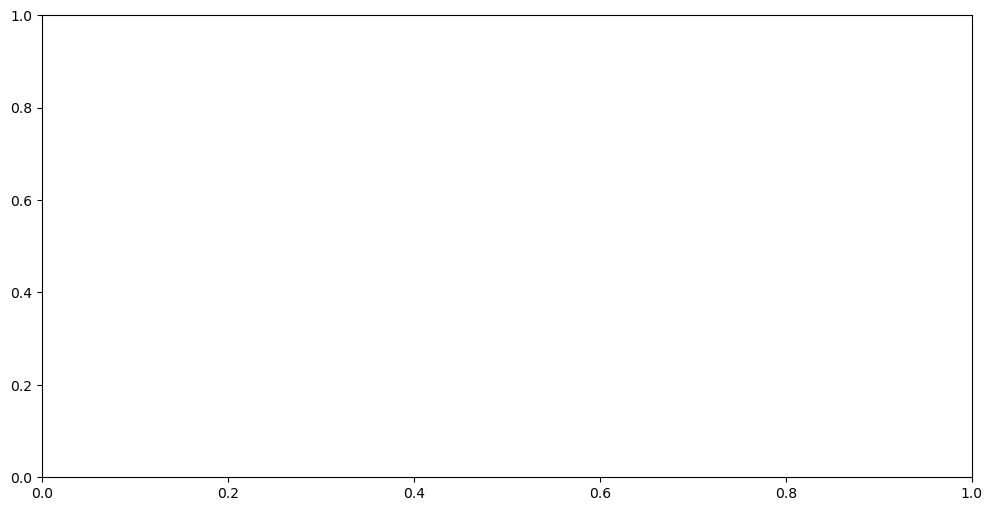

In [111]:
diff = df_L2['height_1_20_ku'] - df_L1['h_surface']
plt.figure(figsize=(12, 6)) 
plt.plot(df_L2['distance'], diff, '.', color='royalblue', markersize=2, label='Surface Height Difference')
plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('Height Difference/m', fontsize=12)
plt.title('Height Difference between L2 and L1', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


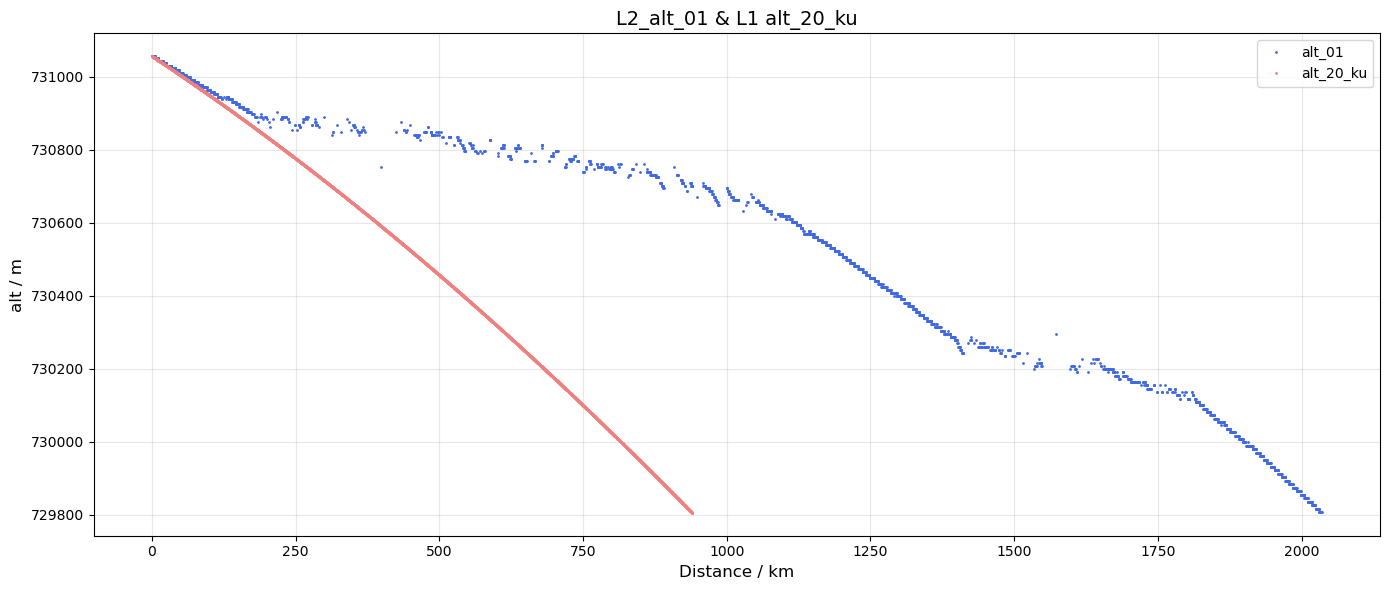

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['alt'], '.', color='royalblue', markersize=2, label='alt_01')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['alt'], '.', color='lightcoral', markersize=2, label='alt_20_ku')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_alt_01 & L1 alt_20_ku', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

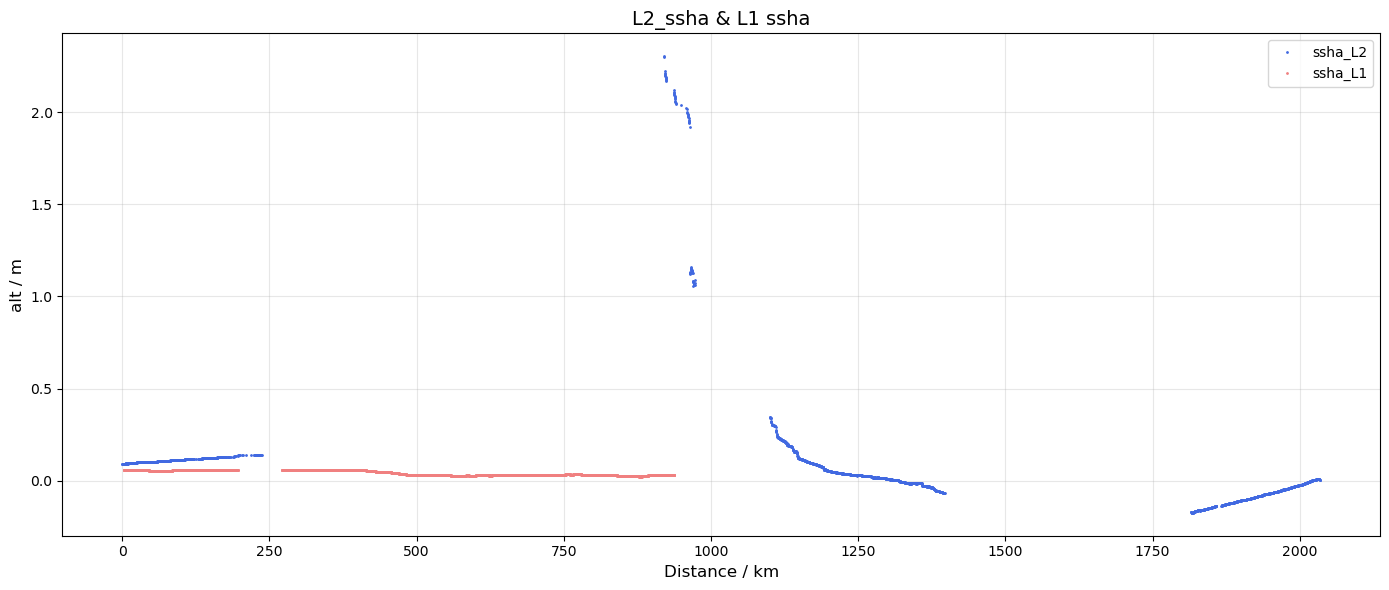

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='royalblue', markersize=2, label='ssha_L2')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['SLA'], '.', color='lightcoral', markersize=2, label='ssha_L1')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_ssha & L1 ssha', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### type comparison

### plot height_ice floe/ height_lead

In [95]:
# 根据 df_L1['type'] 生成 height_sea_ice_floe 和 height_sea_ice_lead
df_L1['height_sea_ice_floe'] = df_L1.loc[df_L1['type'] == 'ice', 'h_surface']
df_L1['height_sea_ice_lead'] = df_L1.loc[df_L1['type'] == 'lead', 'h_surface']
# 创建一个新的 DataFrame 用于比较 L1 和 L2 的 type
comparison_df = pd.DataFrame({
    'L1_type': df_L1['type'],
    'L2_type': df_L2['type_mapped']
})

# 打印前几行以检查
print(comparison_df.head())

KeyError: 'type_mapped'

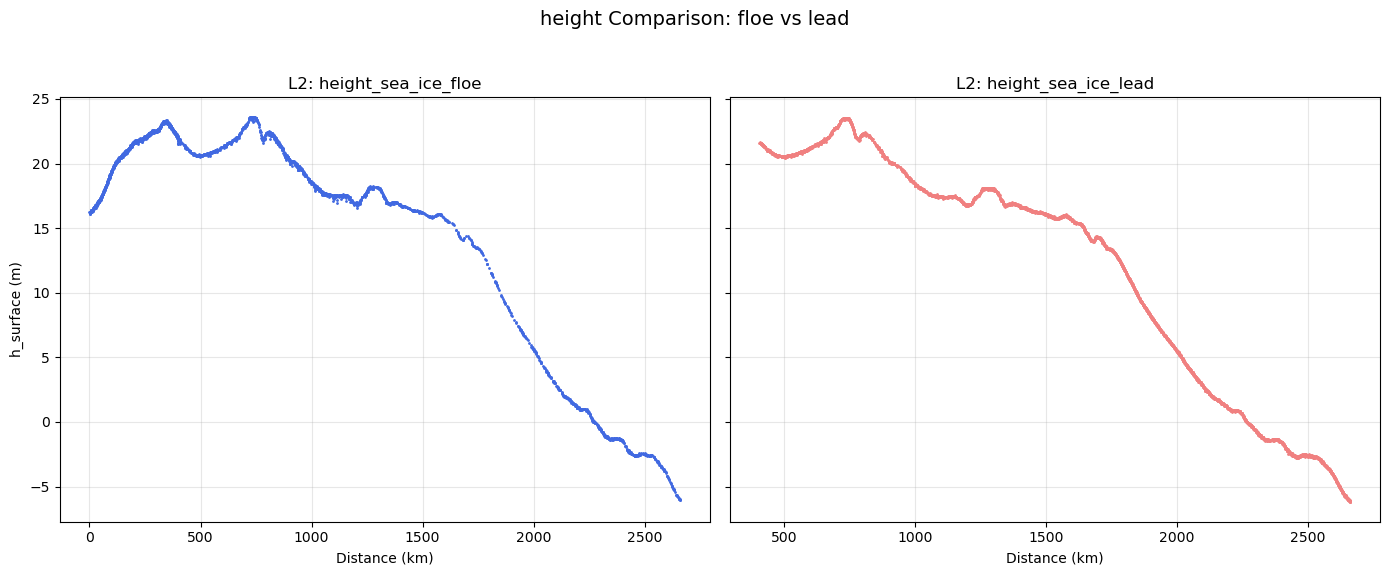

In [147]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L2['distance'], df_L2['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')
axs[0].set_title('L2: height_sea_ice_floe')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')
axs[1].set_title('L2: height_sea_ice_lead')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('height Comparison: floe vs lead', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

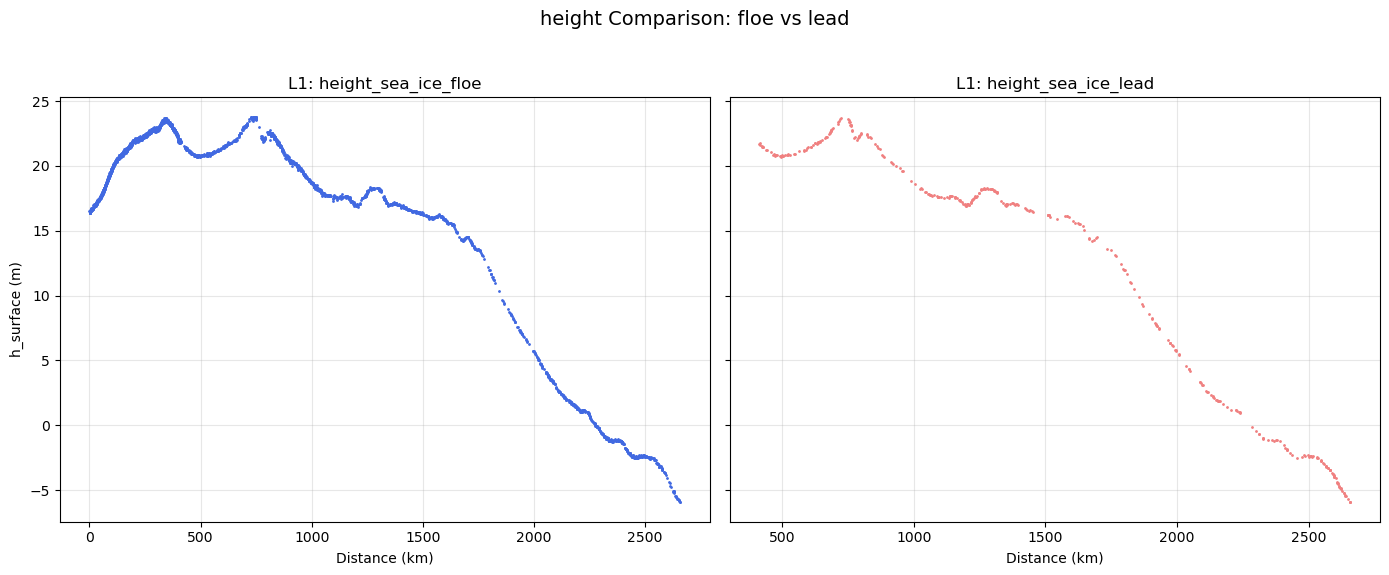

In [146]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')
axs[0].set_title('L1: height_sea_ice_floe')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L1['distance'], df_L1['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')
axs[1].set_title('L1: height_sea_ice_lead')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('height Comparison: floe vs lead', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

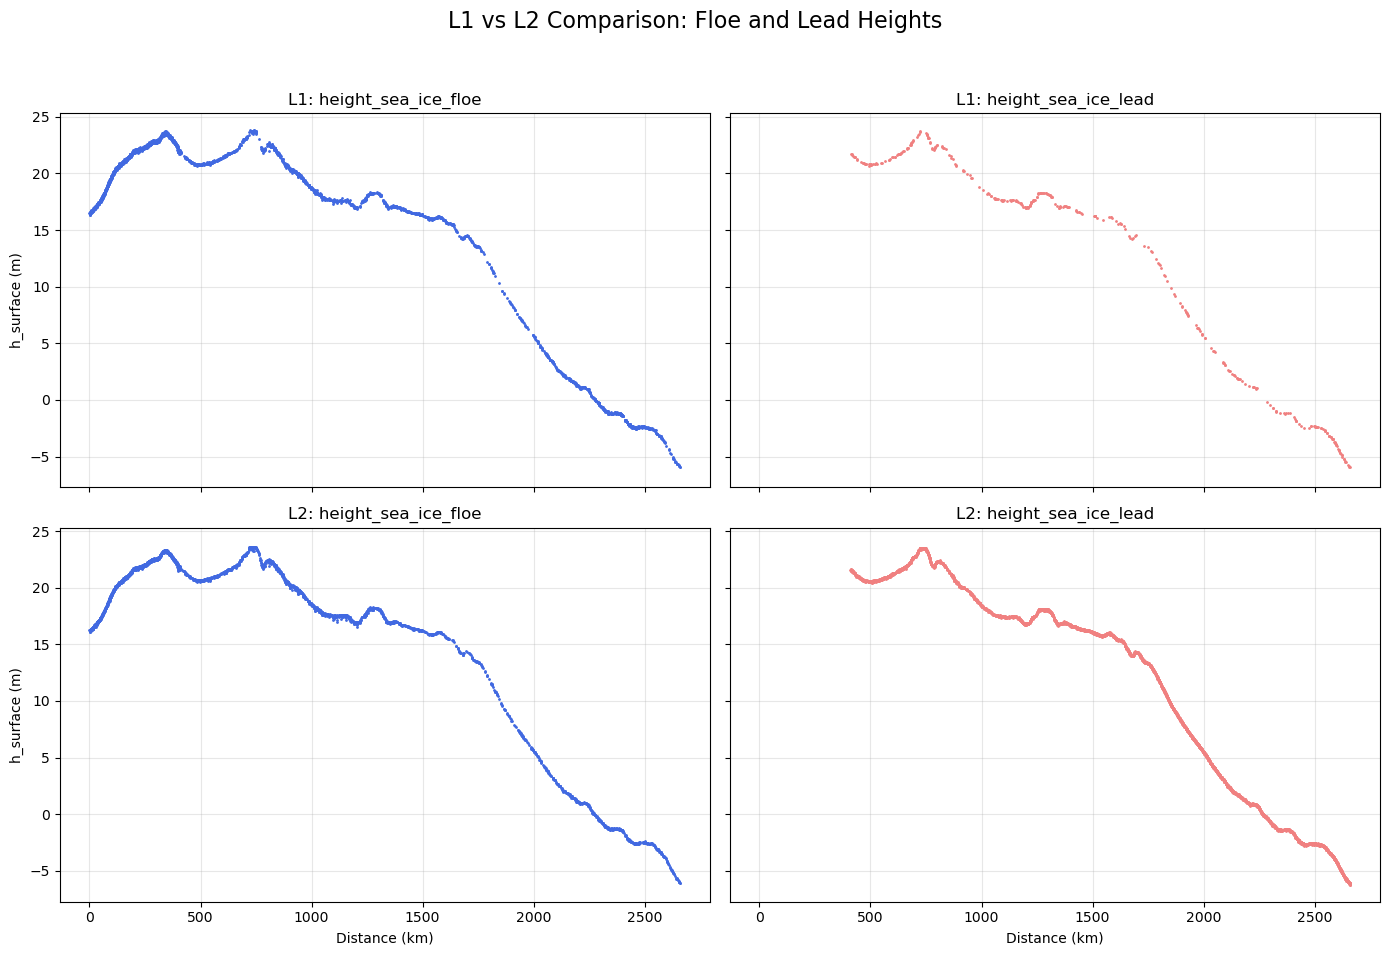

In [148]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# L1: floe
axs[0, 0].plot(df_L1['distance'], df_L1['height_sea_ice_floe'], '.', color='royalblue', markersize=2)
axs[0, 0].set_title('L1: height_sea_ice_floe')
axs[0, 0].set_ylabel('h_surface (m)')
axs[0, 0].grid(alpha=0.3)

# L1: lead
axs[0, 1].plot(df_L1['distance'], df_L1['height_sea_ice_lead'], '.', color='lightcoral', markersize=2)
axs[0, 1].set_title('L1: height_sea_ice_lead')
axs[0, 1].grid(alpha=0.3)

# L2: floe
axs[1, 0].plot(df_L2['distance'], df_L2['height_sea_ice_floe'], '.', color='royalblue', markersize=2)
axs[1, 0].set_title('L2: height_sea_ice_floe')
axs[1, 0].set_xlabel('Distance (km)')
axs[1, 0].set_ylabel('h_surface (m)')
axs[1, 0].grid(alpha=0.3)

# L2: lead
axs[1, 1].plot(df_L2['distance'], df_L2['height_sea_ice_lead'], '.', color='lightcoral', markersize=2)
axs[1, 1].set_title('L2: height_sea_ice_lead')
axs[1, 1].set_xlabel('Distance (km)')
axs[1, 1].grid(alpha=0.3)

plt.suptitle('L1 vs L2 Comparison: Floe and Lead Heights', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


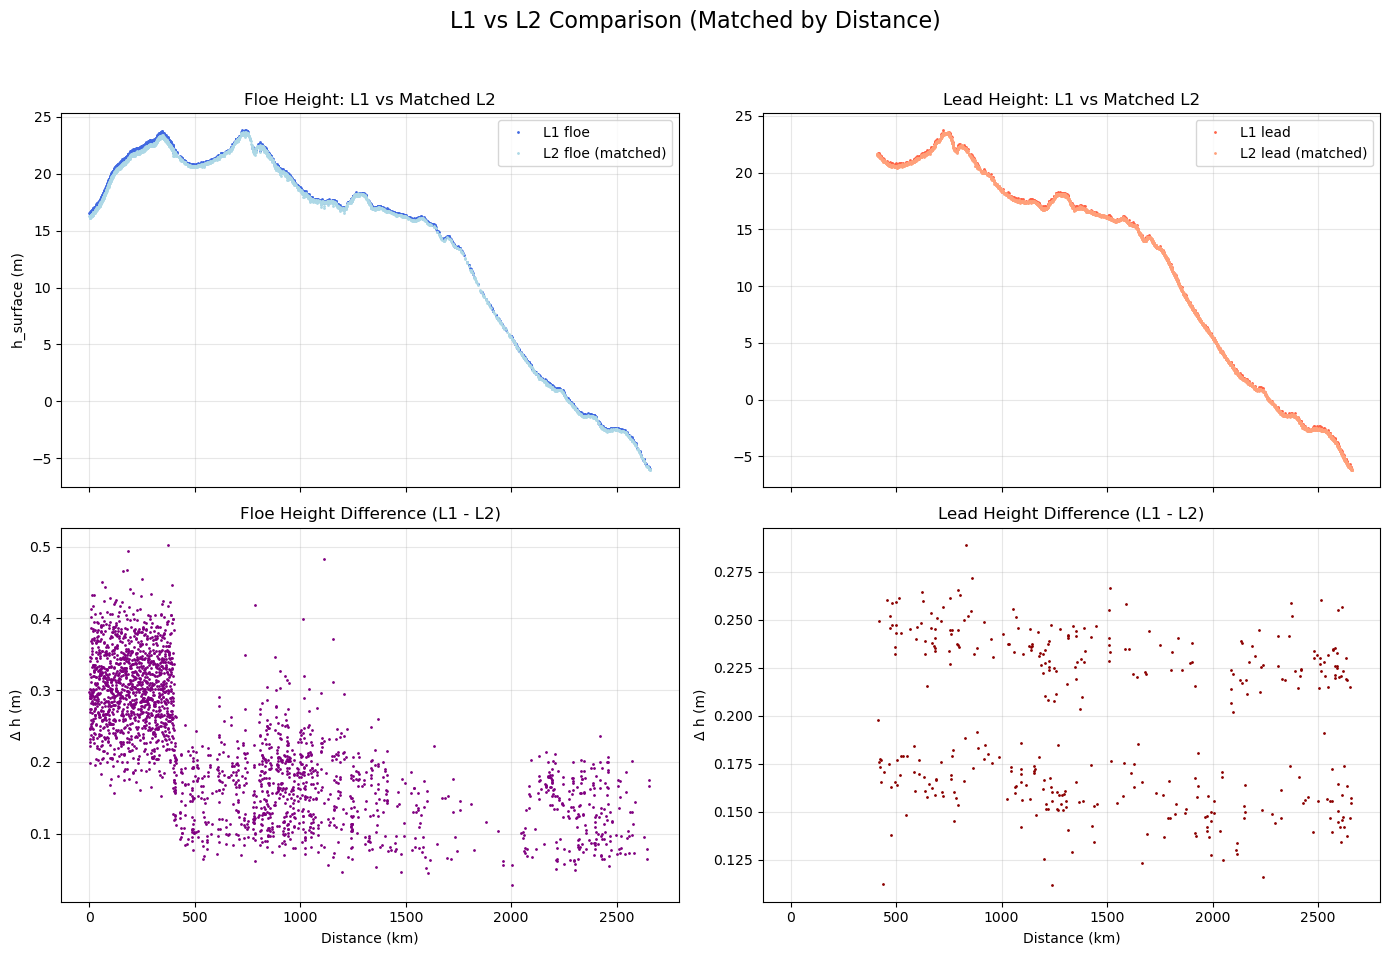

In [149]:
from scipy.spatial import cKDTree
import numpy as np
import matplotlib.pyplot as plt

# 构建 KDTree 对象（用于快速最近邻查找）
tree = cKDTree(df_L2[['distance']])
distances, indices = tree.query(df_L1[['distance']], k=1)

# 取出最近邻匹配的 L2 数据
matched_L2_floe = df_L2.iloc[indices]['height_sea_ice_floe'].values
matched_L2_lead = df_L2.iloc[indices]['height_sea_ice_lead'].values
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# --- FLOE 高度对比 ---
axs[0, 0].plot(df_L1['distance'], df_L1['height_sea_ice_floe'], '.', label='L1 floe', color='royalblue', markersize=2)
axs[0, 0].plot(df_L1['distance'], matched_L2_floe, '.', label='L2 floe (matched)', color='lightblue', markersize=2)
axs[0, 0].set_title('Floe Height: L1 vs Matched L2')
axs[0, 0].set_ylabel('h_surface (m)')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- FLOE 差值 ---
axs[1, 0].plot(df_L1['distance'], df_L1['height_sea_ice_floe'] - matched_L2_floe, '.', color='purple', markersize=2)
axs[1, 0].set_title('Floe Height Difference (L1 - L2)')
axs[1, 0].set_xlabel('Distance (km)')
axs[1, 0].set_ylabel('Δ h (m)')
axs[1, 0].grid(alpha=0.3)

# --- LEAD 高度对比 ---
axs[0, 1].plot(df_L1['distance'], df_L1['height_sea_ice_lead'], '.', label='L1 lead', color='tomato', markersize=2)
axs[0, 1].plot(df_L1['distance'], matched_L2_lead, '.', label='L2 lead (matched)', color='lightsalmon', markersize=2)
axs[0, 1].set_title('Lead Height: L1 vs Matched L2')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

# --- LEAD 差值 ---
axs[1, 1].plot(df_L1['distance'], df_L1['height_sea_ice_lead'] - matched_L2_lead, '.', color='darkred', markersize=2)
axs[1, 1].set_title('Lead Height Difference (L1 - L2)')
axs[1, 1].set_xlabel('Distance (km)')
axs[1, 1].set_ylabel('Δ h (m)')
axs[1, 1].grid(alpha=0.3)

plt.suptitle('L1 vs L2 Comparison (Matched by Distance)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



# freeboard

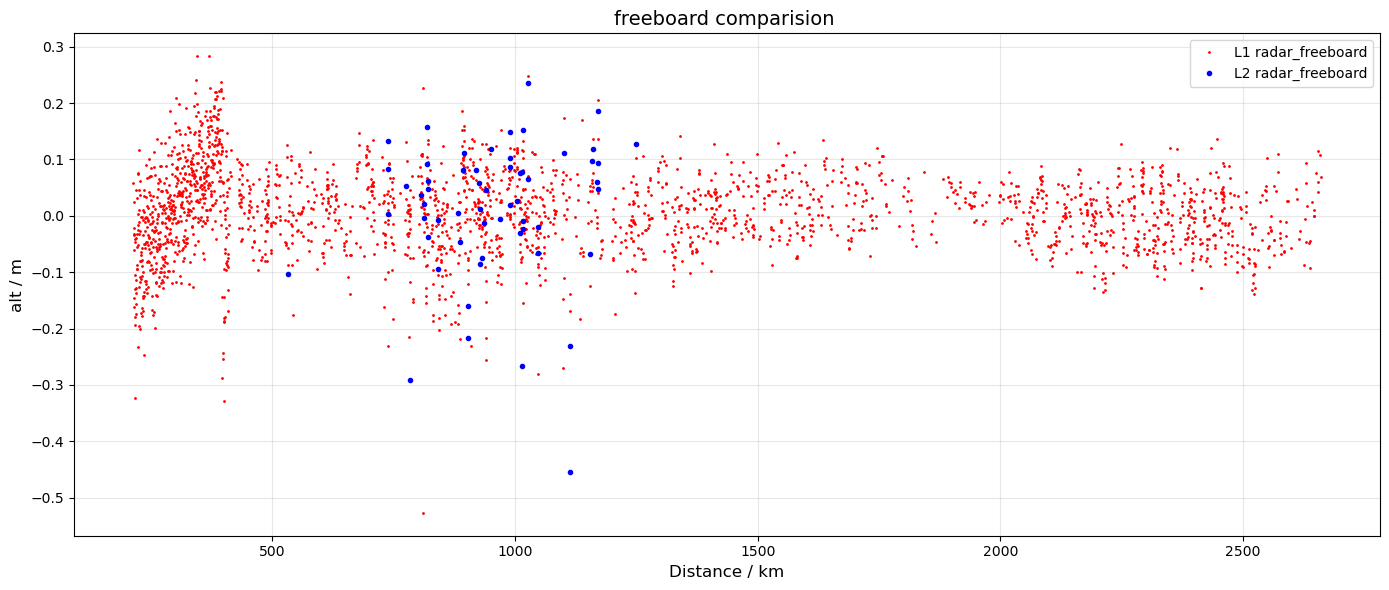

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L1['distance'], df_L1['radar freeboard'], '.', color='red', markersize=2, label='L1 radar_freeboard')
plt.plot(df_L2['distance'], df_L2['radar_freeboard'], '.', color='blue', markersize=6, label='L2 radar_freeboard')  # 增大点的大小

# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('freeboard comparision ', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [180]:
# 假设你有相关的列
df_L2['radar_freeboard_cal'] = df_L2['height_sea_ice_floe'] - (df_L2['mss_seaIce'] + df_L2['ssha'])

# 如果有不确定性数据，可以计算雷达自由板的不确定性
# df_L2['radar_freeboard_uncertainty'] = np.sqrt(df_L2['height_sea_ice_floe_uncertainty']**2 + df_L2['mss_uncertainty']**2 + df_L2['sla_uncertainty']**2)

# 查看结果
print(df_L2[['distance', 'height_sea_ice_floe', 'mss_seaIce', 'ssha', 'radar_freeboard_cal']].head())


   distance  height_sea_ice_floe  mss_seaIce   ssha  radar_freeboard_cal
0  0.000000               16.244      16.137  0.034                0.073
1  0.304336               16.092      16.137  0.034               -0.079
2  0.608674               16.072      16.137  0.034               -0.099
3  0.913004               16.208      16.137  0.033                0.038
4  1.217348               16.196      16.137  0.033                0.026


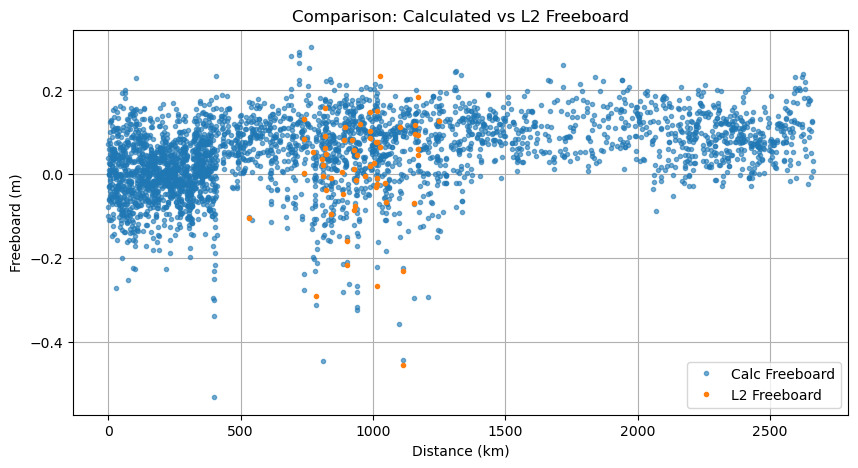

In [183]:
plt.figure(figsize=(10, 5))
plt.plot(df_L2['distance'], df_L2['radar_freeboard_cal'], '.', label='Calc Freeboard', alpha=0.6)
plt.plot(df_L2['distance'], df_L2['radar_freeboard'], '.', label='L2 Freeboard', alpha=1)
plt.xlabel('Distance (km)')
plt.ylabel('Freeboard (m)')
plt.legend()
plt.title('Comparison: Calculated vs L2 Freeboard')
plt.grid(True)
plt.show()


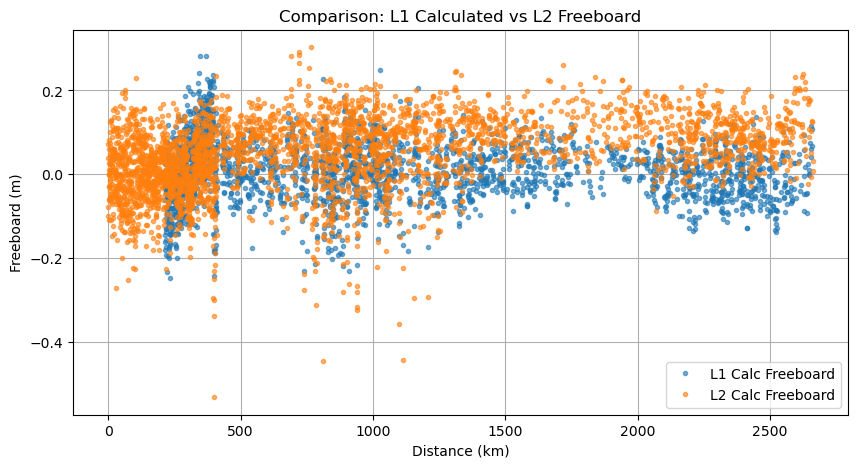

In [196]:
plt.figure(figsize=(10, 5))
plt.plot(df_L1['distance'], df_L1['radar_freeboard'], '.', label='L1 Calc Freeboard', alpha=0.6)
plt.plot(df_L2['distance'], df_L2['radar_freeboard_cal'], '.', label='L2 Calc Freeboard', alpha=0.6)
plt.xlabel('Distance (km)')
plt.ylabel('Freeboard (m)')
plt.legend()
plt.title('Comparison: L1 Calculated vs L2 Freeboard')
plt.grid(True)
plt.show()